In [15]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
from scipy.special import log_ndtr
import string

def logit_transform(f, eps=1e-12):
    f = np.clip(f, eps, 1 - eps)
    return np.log(f / (1.0 - f))


### Figure 1

In [16]:
# Data extract from figure using web plot digitizer
data = [
    (0.9915356711003627, 2.730806963108302),
    (1.9951632406287785, 4.933327249359281),
    (2.986698911729141, 3.3245115709581494),
    (3.9903264812575574, 2.734579027020449),
    (4.993954050785973, 2.3207471120135663),
    (5.985489721886335, 2.196208163172183),
    (6.9770253929866985, 2.398713239488033),
    (7.980652962515114, 0.010038557185552577),
    (8.996372430471583, 0.02389480808864164),
    (10.0, 0.025157232704401622)
]

df = pd.DataFrame(data, columns=["x_raw", "y_log10"])
df["x"] = df["x_raw"].round().astype(int)
df["y"] = 10 ** df["y_log10"]
df = df[["x", "y_log10", "y"]]

t = df["x"].to_numpy(dtype=float)
V = df["y"].to_numpy(dtype=float)

print(df)

    x   y_log10             y
0   1  2.730807    538.030583
1   2  4.933327  85768.388333
2   3  3.324512   2111.113442
3   4  2.734579    542.724000
4   5  2.320747    209.289342
5   6  2.196208    157.111568
6   7  2.398713    250.445504
7   8  0.010039      1.023384
8   9  0.023895      1.056562
9  10  0.025157      1.059637


    x   y_log10             y  detected
0   1  2.730807    538.030583      True
1   2  4.933327  85768.388333      True
2   3  3.324512   2111.113442      True
3   4  2.734579    542.724000      True
4   5  2.320747    209.289342      True
5   6  2.196208    157.111568      True
6   7  2.398713    250.445504      True
7   8  0.010039      1.023384     False
8   9  0.023895      1.056562     False
9  10  0.025157      1.059637     False
Fit success: True
Message: CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL
a       = 2.9290
r       = 3.3589
c       = 1.1132
tau     = 1.9966
sigma   = 1.0519
-logLik = 10.4654
V0      = 18.7086
SSE in ln-space for detected points only = 7.99858


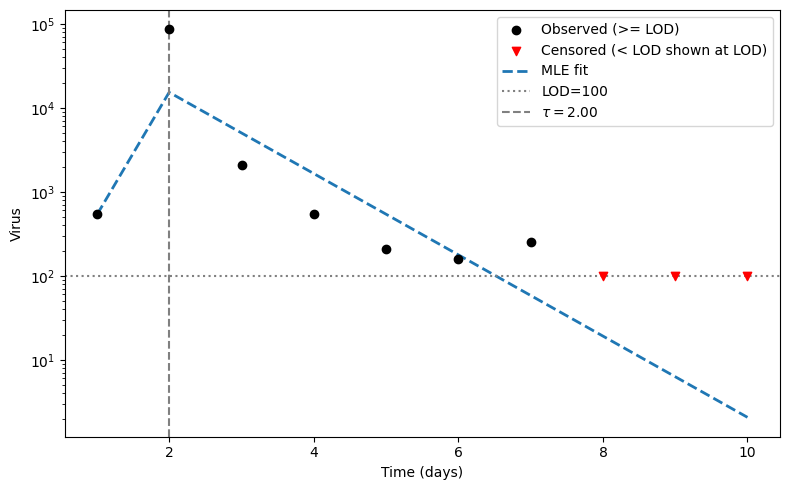

In [17]:
# ------------------------------------------------------------
t = df["x"].to_numpy(dtype=float)
V_obs = df["y"].to_numpy(dtype=float)
y_ln_obs = np.log(V_obs)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
LOD = 100.0
log_LOD = np.log(LOD)

# Mark observations as detected or censored
is_detected = V_obs >= LOD
is_censored = ~is_detected

df["detected"] = is_detected
print(df)

# ------------------------------------------------------------
# Piecewise mean in natural log space
# ln V(t) = a + r*min(t,tau) - c*max(0,t-tau)
# ------------------------------------------------------------
def mu_piecewise_ln(t, a, r, c, tau):
    t = np.asarray(t, dtype=float)
    return a + r * np.minimum(t, tau) - c * np.maximum(0.0, t - tau)

# ------------------------------------------------------------
# Negative log-likelihood with left censoring at LOD
# Gaussian likelihood in NATURAL LOG space
# ------------------------------------------------------------
def neg_loglik_piecewise_censored_ln(params, t, y_ln_obs, is_detected, log_LOD):
    """
    params = [a, r, c, tau, log_sigma]

    Gaussian likelihood in natural log space with left censoring at log_LOD.
    For detected observations, use Gaussian log-pdf.
    For censored observations, use log P(Y <= log_LOD).
    """
    a, r, c, tau, log_sigma = params
    sigma = np.exp(log_sigma)

    # enforce tau inside observed time range
    if tau <= np.min(t) or tau >= np.max(t):
        return np.inf

    # guard against invalid sigma
    if sigma <= 0 or not np.isfinite(sigma):
        return np.inf

    mu = mu_piecewise_ln(t, a, r, c, tau)

    ll = 0.0

    # detected observations: Gaussian log-pdf
    if np.any(is_detected):
        ll += np.sum(
            norm.logpdf(
                y_ln_obs[is_detected],
                loc=mu[is_detected],
                scale=sigma
            )
        )

    # censored observations: log Gaussian CDF up to log_LOD
    cens = ~is_detected
    if np.any(cens):
        z = (log_LOD - mu[cens]) / sigma
        ll += np.sum(log_ndtr(z))

    return -ll

# ------------------------------------------------------------
# Fit by MLE
# ------------------------------------------------------------
def fit_piecewise_censored_ln_mle(t, y_ln_obs, V_obs, LOD=100.0):
    t = np.asarray(t, dtype=float)
    y_ln_obs = np.asarray(y_ln_obs, dtype=float)
    V_obs = np.asarray(V_obs, dtype=float)

    log_LOD = np.log(LOD)
    is_detected = V_obs >= LOD

    # Initial guesses
    tau0 = t[np.argmax(V_obs)]   # peak on original scale
    a0 = y_ln_obs[0]
    r0 = max((np.max(y_ln_obs) - y_ln_obs[0]) / max(tau0 - t[0], 1e-6), 0.1)
    c0 = 1.0

    mu0 = mu_piecewise_ln(t, a0, r0, c0, tau0)
    resid0 = y_ln_obs[is_detected] - mu0[is_detected]
    sigma0 = np.std(resid0) if np.sum(is_detected) >= 2 else 0.5
    sigma0 = max(float(sigma0), 0.1)

    x0 = np.array([a0, r0, c0, tau0, np.log(sigma0)])

    # bounds: a, r, c, tau, log_sigma
    bounds = [
        (-20.0, 20.0),                          # a = ln(V0)
        (-10.0, 10.0),                          # r
        (-10.0, 10.0),                          # c
        (np.min(t) + 1e-6, np.max(t) - 1e-6),  # tau
        (np.log(1e-4), np.log(20.0))           # sigma
    ]

    res = minimize(
        neg_loglik_piecewise_censored_ln,
        x0=x0,
        args=(t, y_ln_obs, is_detected, log_LOD),
        method="L-BFGS-B",
        bounds=bounds
    )

    a_hat, r_hat, c_hat, tau_hat, log_sigma_hat = res.x
    sigma_hat = np.exp(log_sigma_hat)

    return {
        "a": float(a_hat),
        "r": float(r_hat),
        "c": float(c_hat),
        "tau": float(tau_hat),
        "sigma": float(sigma_hat),
        "negloglik": float(res.fun),
        "success": bool(res.success),
        "message": res.message,
        "is_detected": is_detected,
        "is_censored": ~is_detected
    }

# ------------------------------------------------------------
# Run fit
# ------------------------------------------------------------
fit = fit_piecewise_censored_ln_mle(t, y_ln_obs, V_obs, LOD=LOD)

a_hat = fit["a"]
r_hat = fit["r"]
c_hat = fit["c"]
tau_hat = fit["tau"]
sigma_hat = fit["sigma"]

print("Fit success:", fit["success"])
print("Message:", fit["message"])
print(f"a       = {a_hat:.4f}")
print(f"r       = {r_hat:.4f}")
print(f"c       = {c_hat:.4f}")
print(f"tau     = {tau_hat:.4f}")
print(f"sigma   = {sigma_hat:.4f}")
print(f"-logLik = {fit['negloglik']:.4f}")
print(f"V0      = {np.exp(a_hat):.4f}")

# ------------------------------------------------------------
# Fitted mean curves
# ------------------------------------------------------------
t_eval = np.linspace(np.min(t), np.max(t), 500)
mu_hat_eval = mu_piecewise_ln(t_eval, a_hat, r_hat, c_hat, tau_hat)
V_hat_eval = np.exp(mu_hat_eval)

mu_hat_obs = mu_piecewise_ln(t, a_hat, r_hat, c_hat, tau_hat)
V_hat_obs = np.exp(mu_hat_obs)

# optional: approximate residual summaries for detected points
resid_detected_ln = y_ln_obs[is_detected] - mu_hat_obs[is_detected]
print(f"SSE in ln-space for detected points only = {np.sum(resid_detected_ln**2):.6g}")

# ------------------------------------------------------------
# Plot in original scale
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(
    t[is_detected],
    V_obs[is_detected],
    color="black",
    label="Observed (>= LOD)",
    zorder=5
)
plt.scatter(
    t[is_censored],
    np.repeat(LOD, np.sum(is_censored)),
    marker="v",
    color="red",
    label="Censored (< LOD shown at LOD)",
    zorder=5
)
plt.plot(t_eval, V_hat_eval, "--", linewidth=2, label="MLE fit")
plt.axhline(LOD, color="gray", linestyle=":", label=f"LOD={LOD:g}")
plt.axvline(tau_hat, color="gray", linestyle="--", label=f"$\\tau={tau_hat:.2f}$")
plt.yscale("log")
plt.xlabel("Time (days)")
plt.ylabel("Virus")
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# Helper: adaptive-immune-response infected-cell death rate
# ============================================================
def delta_adaptive(t, delta_I, mu, sigma):
    """
    Time-varying infected-cell death rate:
      delta(t) = delta_I                         for t < mu
               = delta_I * exp(sigma * (t-mu))  for t >= mu
    """
    if t < mu:
        return delta_I
    return delta_I * np.exp(sigma * (t - mu))


# ============================================================
# Panel A: stochastic TIRVF model with adaptive immune response
# ============================================================
def simulate_TIRVF_two_strain_EM(
    t, T0, I10, I20, R0, V10, V20, F0,
    beta, phi, rho_R, delta_I, mu, sigma, kappa,
    p, c, q, d, epsilon, rho_env, seed=None
):
    """
    Euler-Maruyama simulation of a two-strain stochastic TIRVF model.

    State variables:
        T   : target cells
        I1  : infected cells, strain 1
        I2  : infected cells, strain 2
        R   : refractory cells
        V1  : virus strain 1
        V2  : virus strain 2
        F   : interferon

    Adaptive immune response enters through the infected-cell death rate:
        delta(t) = delta_I                       for t < mu
                 = delta_I * exp(sigma*(t-mu))  for t >= mu
    """
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")
    if not (-1.0 <= rho_env <= 1.0):
        raise ValueError("rho_env must be in [-1, 1].")

    rng = np.random.default_rng(seed)
    n = len(t)

    T  = np.empty(n, dtype=float)
    I1 = np.empty(n, dtype=float)
    I2 = np.empty(n, dtype=float)
    R  = np.empty(n, dtype=float)
    V1 = np.empty(n, dtype=float)
    V2 = np.empty(n, dtype=float)
    F  = np.empty(n, dtype=float)

    T[0], I1[0], I2[0], R[0], V1[0], V2[0], F[0] = (
        float(T0), float(I10), float(I20), float(R0),
        float(V10), float(V20), float(F0)
    )

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        tk = t[k]
        delta_t = delta_adaptive(tk, delta_I=delta_I, mu=mu, sigma=sigma)

        cov = dt * np.array([
            [1.0, rho_env],
            [rho_env, 1.0]
        ], dtype=float)
        dW1, dW2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov)

        # deterministic drifts
        dT_det  = (-beta * T[k] * (V1[k] + V2[k]) - phi * F[k] * T[k] + rho_R * R[k]) * dt
        dI1_det = ( beta * T[k] * V1[k] - delta_t * I1[k] - kappa * F[k] * I1[k]) * dt
        dI2_det = ( beta * T[k] * V2[k] - delta_t * I2[k] - kappa * F[k] * I2[k]) * dt
        dR_det  = ( phi * F[k] * T[k] - rho_R * R[k]) * dt
        dV1_det = ( p * I1[k] - c * V1[k]) * dt
        dV2_det = ( p * I2[k] - c * V2[k]) * dt
        dF_det  = ( q * (I1[k] + I2[k]) - d * F[k]) * dt

        # multiplicative environmental noise on viral populations
        dV1_sto = epsilon  * V1[k] * dW1
        dV2_sto = epsilon  * V2[k] * dW2

        # Euler-Maruyama updates
        T[k + 1]  = max(T[k]  + dT_det,  0.0)
        I1[k + 1] = max(I1[k] + dI1_det, 0.0)
        I2[k + 1] = max(I2[k] + dI2_det, 0.0)
        R[k + 1]  = max(R[k]  + dR_det,  0.0)
        V1[k + 1] = max(V1[k] + dV1_det + dV1_sto, 0.0)
        V2[k + 1] = max(V2[k] + dV2_det + dV2_sto, 0.0)
        F[k + 1]  = max(F[k]  + dF_det,  0.0)

    return T, I1, I2, R, V1, V2, F


# ============================================================
# Parameters for Panel A
# ============================================================
beta   = 8.36e-6
phi    = 6.9e-2
rho_R  = 0.01
kappa  = 1.6
p      = 7.7e-5
c      = 20.0
q      = 6.1e-10
d      = 0.85

epsilon = 0.2
rho_env = 0.2

# adaptive immune response parameters
delta_I = 2.0    # baseline infected-cell death rate before mu days
mu_adapt = 7.0   # adaptive response starts at day 4
sigma = 1      # speed of increase after mu

# initial conditions
T0   = 3.5e11
I10  = 0.0
I20  = 0.0
R0   = 0.0
V10  = 12.0
V20  = 0.0
F0   = 0.0

seed    = 42

# ============================================================
# Panel B: your existing two-strain multivariate simulation
# ============================================================
def simulate_two_strain_EM_multivariate(
    t, V10, V20, r, c, tau, epsilon, rho, seed=None
):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if V10 < 0 or V20 < 0:
        raise ValueError("V10 and V20 must be positive.")

    rng = np.random.default_rng(seed)
    n = len(t)

    V1_A = np.empty(n, dtype=float)
    V2_A = np.empty(n, dtype=float)
    V1_A[0], V2_A[0] = float(V10), float(V20)

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        mu_piece = r if t[k] < tau else -c

        cov = dt * np.array([[1.0, rho],
                             [rho, 1.0]], dtype=float)

        dW1, dW2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov)

        V1_A[k + 1] = V1_A[k] + mu_piece * V1_A[k] * dt + epsilon  * V1_A[k] * dW1
        V2_A[k + 1] = V2_A[k] + mu_piece * V2_A[k] * dt + epsilon  * V2_A[k] * dW2

        V1_A[k + 1] = max(V1_A[k + 1], 0.0)
        V2_A[k + 1] = max(V2_A[k + 1], 0.0)

    denom = V1_A + V2_A
    f2_A = np.divide(V2_A, denom, out=np.zeros_like(V2_A), where=denom > 0)

    return V1_A, V2_A, f2_A

# ============================================================
# Parameters for Panel B
# ============================================================
t_eval_B = np.linspace(0, 10, 10001)

tau_hat = 2.2943
r_hat   = 6.5983
c_hat   = 2.9031
logV0   = -1.4116

V10_B = np.exp(logV0)

epsilon_B = 0.2
rho_B = 0


In [19]:
# ============================================================
# Observed data
# ============================================================
t_obs = df["x"].to_numpy(dtype=float)
V_obs = df["y"].to_numpy(dtype=float)

LOD = 100.0

# ============================================================
# Panel A: stochastic TIRVF model
# ============================================================
t_eval_A = np.linspace(0.0, 10.0, 10000)

eps_list = [0.0, 0.5, 1]
color_map = {
    0.0: "blue",
    0.5: "orange",
    1: "purple"
}

beta   = 8.36e-6
phi    = 6.9e-2
rho_R  = 0.01
kappa  = 1.6
p      = 7.7e-5
c      = 20.0
q      = 6.1e-10
d      = 0.85

epsilon = 0.2
rho_env = 0.2

# adaptive immune response parameters
delta_I = 2.0    # baseline infected-cell death rate before mu days
mu_adapt = 7.0   # adaptive response starts at day 4
sigma = 1      # speed of increase after mu

# initial conditions
T0   = 3.5e11
I10  = 0.0
I20  = 0.0
R0   = 0.0
V10  = 1
V20  = 0.0
F0   = 0

seed    = 42

V1_panelA = {}
rng = np.random.default_rng(3299)
seeds = rng.integers(0, 1_000_000, size=len(eps_list))

for seed, eps in zip(seeds, eps_list):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_two_strain_EM(
        t=t_eval_A,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon=eps, rho_env=rho_env,
        seed=int(seed)
    )
    V1_panelA[eps] = np.maximum(V1_tmp, 1e-12)  # avoid log-scale issues


# ============================================================
# Panel B: piecewise exponential model (NATURAL LOG parameters)
# ============================================================
a_hat   = fit["a"]     # ln(V0)
r_hat   = fit["r"]
c_hat   = fit["c"]
tau_hat = fit["tau"]

V10_B = np.exp(a_hat)   # IMPORTANT: natural log → original scale
V20_B = 0.0

t_eval_B = np.linspace(0.0, 10.0, 10000)

V1_panelB = {}
for eps, seeds in zip(eps_list, seeds):
    V1_tmp, V2_tmp, f2_tmp = simulate_two_strain_EM_multivariate(
        t=t_eval_B,
        V10=V10_B,
        V20=V20_B,
        r=r_hat,
        c=c_hat,
        tau=tau_hat,
        epsilon=eps,
        rho=rho_B,
        seed= int(seeds)
    )
    V1_panelB[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Print fitted parameters (natural log)
# ============================================================
print("MLE parameters (natural log space):")
print(f"a_hat   = {a_hat:.4f}  (ln V0)")
print(f"r_hat   = {r_hat:.4f}")
print(f"c_hat   = {c_hat:.4f}")
print(f"tau_hat = {tau_hat:.4f}")
print(f"V0      = {np.exp(a_hat):.4f}")

MLE parameters (natural log space):
a_hat   = 2.9290  (ln V0)
r_hat   = 3.3589
c_hat   = 1.1132
tau_hat = 1.9966
V0      = 18.7086


MLE parameters (natural log space):
a_hat   = 2.9290  (ln V0)
r_hat   = 3.3589
c_hat   = 1.1132
tau_hat = 1.9966
V0      = 18.7086
MLE parameters (natural log space):
a_hat   = 2.9290  (ln V0)
r_hat   = 3.3589
c_hat   = 1.1132
tau_hat = 1.9966
V0      = 18.7086


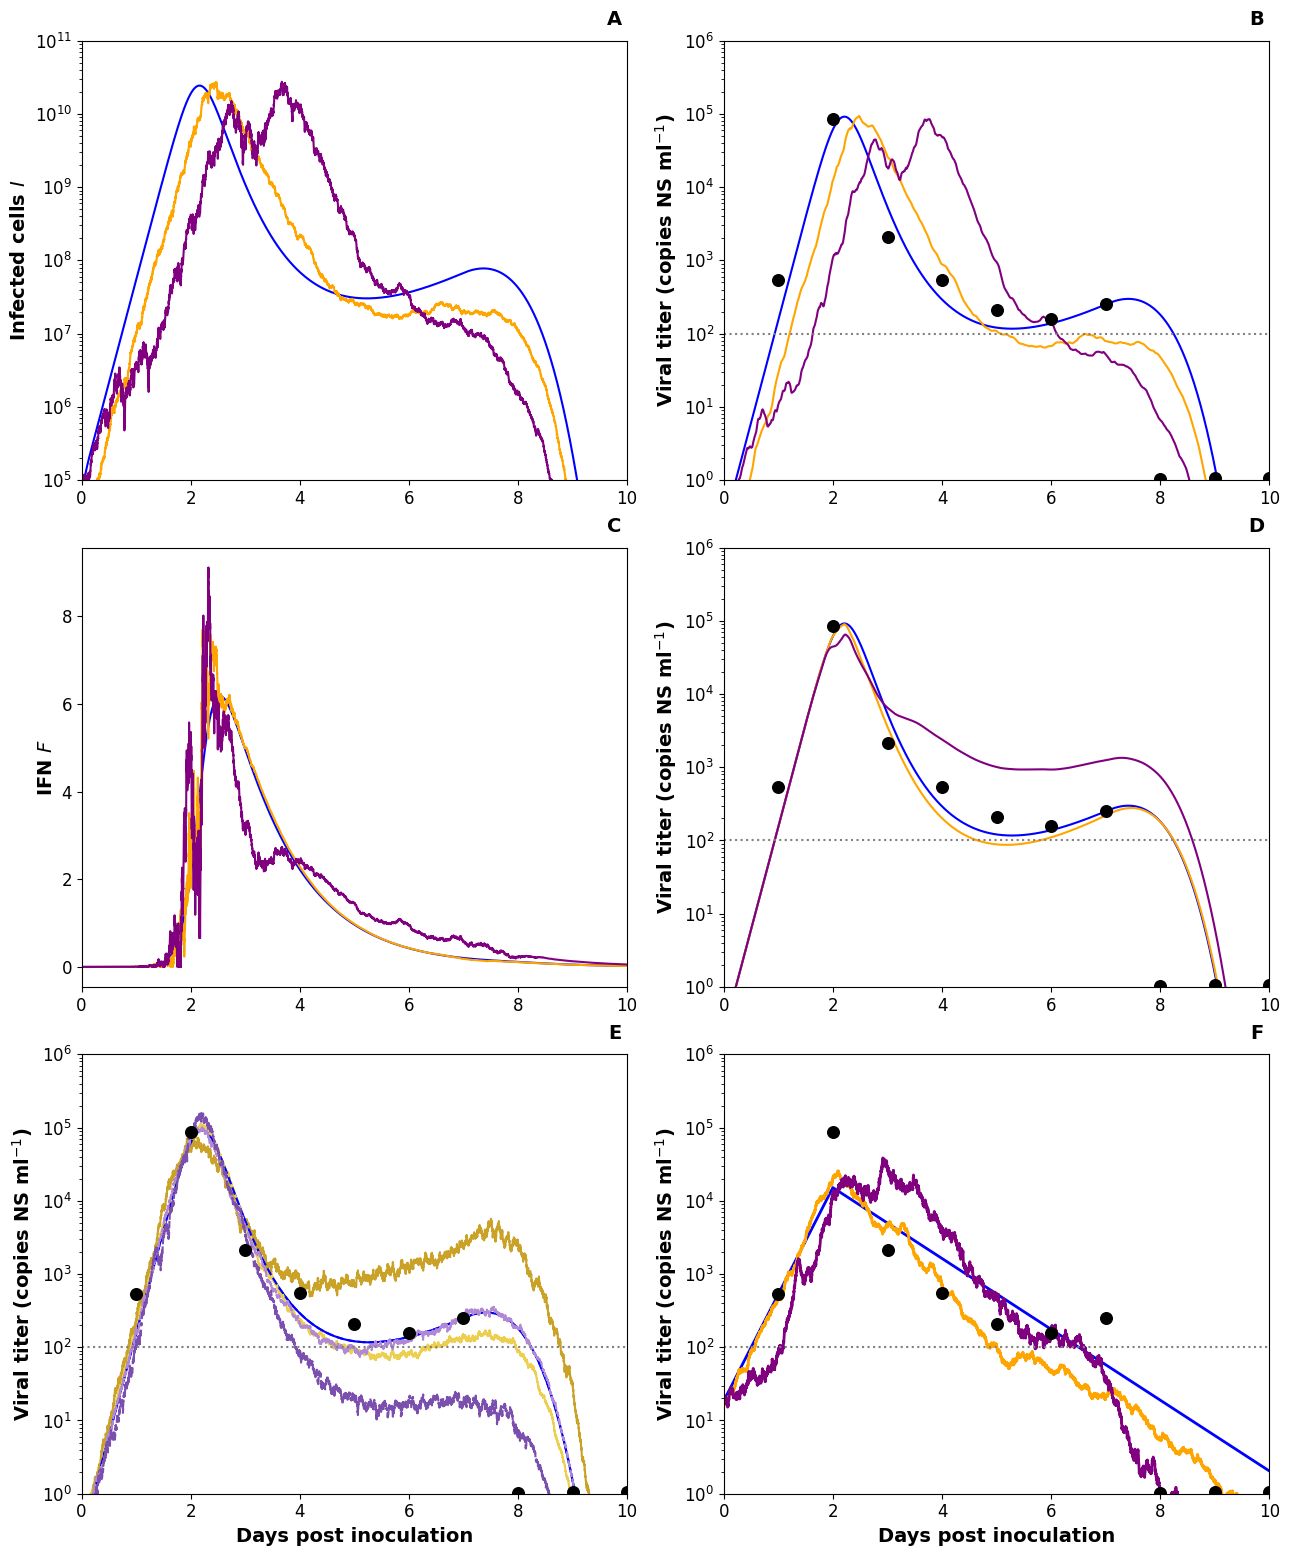

In [20]:
# ============================================================
# Panel B: TIRVF model with environmental stochasticity on q / IFN production
# dF = q(I1+I2)dt - dFdt + epsilon(I1+I2)dW
# ============================================================

def simulate_TIRVF_noise_q_EM(
    t, T0, I10, I20, R0, V10, V20, F0,
    beta, phi, rho_R, delta_I, mu, sigma, kappa,
    p, c, q, d, epsilon_q, seed=None
):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")

    rng = np.random.default_rng(seed)
    n = len(t)

    T  = np.empty(n, dtype=float)
    I1 = np.empty(n, dtype=float)
    I2 = np.empty(n, dtype=float)
    R  = np.empty(n, dtype=float)
    V1 = np.empty(n, dtype=float)
    V2 = np.empty(n, dtype=float)
    F  = np.empty(n, dtype=float)

    T[0], I1[0], I2[0], R[0], V1[0], V2[0], F[0] = (
        float(T0), float(I10), float(I20), float(R0),
        float(V10), float(V20), float(F0)
    )

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        delta_t = delta_adaptive(t[k], delta_I=delta_I, mu=mu, sigma=sigma)
        dW = rng.normal(0.0, np.sqrt(dt))

        I_total = I1[k] + I2[k]

        dT_det  = (-beta * T[k] * (V1[k] + V2[k]) - phi * F[k] * T[k] + rho_R * R[k]) * dt
        dI1_det = ( beta * T[k] * V1[k] - delta_t * I1[k] - kappa * F[k] * I1[k]) * dt
        dI2_det = ( beta * T[k] * V2[k] - delta_t * I2[k] - kappa * F[k] * I2[k]) * dt
        dR_det  = ( phi * F[k] * T[k] - rho_R * R[k]) * dt
        dV1_det = ( p * I1[k] - c * V1[k]) * dt
        dV2_det = ( p * I2[k] - c * V2[k]) * dt
        dF_det  = ( q * I_total - d * F[k]) * dt

        # stochasticity on IFN production term
        dF_sto = epsilon_q * I_total * dW

        T[k + 1]  = max(T[k]  + dT_det,  0.0)
        I1[k + 1] = max(I1[k] + dI1_det, 0.0)
        I2[k + 1] = max(I2[k] + dI2_det, 0.0)
        R[k + 1]  = max(R[k]  + dR_det,  0.0)
        V1[k + 1] = max(V1[k] + dV1_det, 0.0)
        V2[k + 1] = max(V2[k] + dV2_det, 0.0)
        F[k + 1]  = max(F[k]  + dF_det + dF_sto, 0.0)

    return T, I1, I2, R, V1, V2, F


# ============================================================
# Panel C: TIRVF model with environmental stochasticity on beta / infection term
# Scaled version:
# deterministic infection: beta * T * V * dt
# stochastic infection:   epsilon * beta * T * V * dW
# ============================================================

def simulate_TIRVF_noise_beta_EM(
    t, T0, I10, I20, R0, V10, V20, F0,
    beta, phi, rho_R, delta_I, mu, sigma, kappa,
    p, c, q, d, epsilon_beta, seed=None
):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")

    rng = np.random.default_rng(seed)
    n = len(t)

    T  = np.empty(n, dtype=float)
    I1 = np.empty(n, dtype=float)
    I2 = np.empty(n, dtype=float)
    R  = np.empty(n, dtype=float)
    V1 = np.empty(n, dtype=float)
    V2 = np.empty(n, dtype=float)
    F  = np.empty(n, dtype=float)

    T[0], I1[0], I2[0], R[0], V1[0], V2[0], F[0] = (
        float(T0), float(I10), float(I20), float(R0),
        float(V10), float(V20), float(F0)
    )

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        delta_t = delta_adaptive(t[k], delta_I=delta_I, mu=mu, sigma=sigma)
        dW = rng.normal(0.0, np.sqrt(dt))

        V_total = V1[k] + V2[k]

        dT_det  = (-beta * T[k] * V_total - phi * F[k] * T[k] + rho_R * R[k]) * dt
        dI1_det = ( beta * T[k] * V1[k] - delta_t * I1[k] - kappa * F[k] * I1[k]) * dt
        dI2_det = ( beta * T[k] * V2[k] - delta_t * I2[k] - kappa * F[k] * I2[k]) * dt
        dR_det  = ( phi * F[k] * T[k] - rho_R * R[k]) * dt
        dV1_det = ( p * I1[k] - c * V1[k]) * dt
        dV2_det = ( p * I2[k] - c * V2[k]) * dt
        dF_det  = ( q * (I1[k] + I2[k]) - d * F[k]) * dt

        # stochasticity on beta / infection ("viral production") term
        dInf_sto_total = epsilon_beta * T[k] * V_total * dW

        if V_total > 0:
            frac1 = V1[k] / V_total
            frac2 = V2[k] / V_total
        else:
            frac1 = 0.0
            frac2 = 0.0

        dT_sto  = -dInf_sto_total
        dI1_sto =  frac1 * dInf_sto_total
        dI2_sto =  frac2 * dInf_sto_total

        T[k + 1]  = max(T[k]  + dT_det  + dT_sto,  0.0)
        I1[k + 1] = max(I1[k] + dI1_det + dI1_sto, 0.0)
        I2[k + 1] = max(I2[k] + dI2_det + dI2_sto, 0.0)
        R[k + 1]  = max(R[k]  + dR_det,  0.0)
        V1[k + 1] = max(V1[k] + dV1_det, 0.0)
        V2[k + 1] = max(V2[k] + dV2_det, 0.0)
        F[k + 1]  = max(F[k]  + dF_det, 0.0)

        if not np.all(np.isfinite([T[k+1], I1[k+1], I2[k+1], R[k+1], V1[k+1], V2[k+1], F[k+1]])):
            T[k+1:]  = np.nan
            I1[k+1:] = np.nan
            I2[k+1:] = np.nan
            R[k+1:]  = np.nan
            V1[k+1:] = np.nan
            V2[k+1:] = np.nan
            F[k+1:]  = np.nan
            break

    return T, I1, I2, R, V1, V2, F


# ============================================================
# Environmental noise on VIRUS PRODUCTION (p) rather than clearance (c)
#   dV_i = (p*I_i - c*V_i) dt + epsilon_p * I_i * dW_i
# Strain-specific Wiener increments, correlated via rho_env (same convention
# as simulate_TIRVF_two_strain_EM, so the two panels are comparable).
# ============================================================
def simulate_TIRVF_noise_p_EM(
    t, T0, I10, I20, R0, V10, V20, F0,
    beta, phi, rho_R, delta_I, mu, sigma, kappa,
    p, c, q, d, epsilon_p, rho_env=0.0, seed=None
):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")

    rng = np.random.default_rng(seed)
    n = len(t)

    T  = np.empty(n, dtype=float)
    I1 = np.empty(n, dtype=float)
    I2 = np.empty(n, dtype=float)
    R  = np.empty(n, dtype=float)
    V1 = np.empty(n, dtype=float)
    V2 = np.empty(n, dtype=float)
    F  = np.empty(n, dtype=float)

    T[0], I1[0], I2[0], R[0], V1[0], V2[0], F[0] = (
        float(T0), float(I10), float(I20), float(R0),
        float(V10), float(V20), float(F0)
    )

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        delta_t = delta_adaptive(t[k], delta_I=delta_I, mu=mu, sigma=sigma)

        # correlated increments for the two strains
        z1, z2 = rng.normal(0.0, 1.0, size=2)
        dW1 = np.sqrt(dt) * z1
        dW2 = np.sqrt(dt) * (rho_env * z1 + np.sqrt(max(1.0 - rho_env**2, 0.0)) * z2)

        I_total = I1[k] + I2[k]

        # deterministic drifts (identical to the other TIRVF variants)
        dT_det  = (-beta * T[k] * (V1[k] + V2[k]) - phi * F[k] * T[k] + rho_R * R[k]) * dt
        dI1_det = ( beta * T[k] * V1[k] - delta_t * I1[k] - kappa * F[k] * I1[k]) * dt
        dI2_det = ( beta * T[k] * V2[k] - delta_t * I2[k] - kappa * F[k] * I2[k]) * dt
        dR_det  = ( phi * F[k] * T[k] - rho_R * R[k]) * dt
        dV1_det = ( p * I1[k] - c * V1[k]) * dt
        dV2_det = ( p * I2[k] - c * V2[k]) * dt
        dF_det  = ( q * I_total - d * F[k]) * dt

        # stochasticity on the production term p*I  (scales with infected cells)
        dV1_sto = epsilon_p * I1[k] * dW1
        dV2_sto = epsilon_p * I2[k] * dW2

        T[k + 1]  = max(T[k]  + dT_det,  0.0)
        I1[k + 1] = max(I1[k] + dI1_det, 0.0)
        I2[k + 1] = max(I2[k] + dI2_det, 0.0)
        R[k + 1]  = max(R[k]  + dR_det,  0.0)
        V1[k + 1] = max(V1[k] + dV1_det + dV1_sto, 0.0)
        V2[k + 1] = max(V2[k] + dV2_det + dV2_sto, 0.0)
        F[k + 1]  = max(F[k]  + dF_det,  0.0)

        if not np.all(np.isfinite([T[k+1], I1[k+1], I2[k+1],
                                   R[k+1], V1[k+1], V2[k+1], F[k+1]])):
            for arr in (T, I1, I2, R, V1, V2, F):
                arr[k+1:] = np.nan
            break

    return T, I1, I2, R, V1, V2, F



# ============================================================
# Time grids (shared across all panels)
# ============================================================
t_eval = np.linspace(0.0, 10.0, 10000)

# Distinct epsilon sweeps per noise source -- magnitudes differ a lot by
# mechanism (beta/q act on very different scales than c), so each row uses
# its own list of values.
eps_list_beta = [0.0, 8e-07, 1.5e-06]   # noise in viral production (beta / infection term)
eps_list_q    = [0.0, 3e-10, 6e-10]   # noise in IFN production (q)
eps_list_c    = [0.0, 0.5, 1.0]       # noise in viral clearance (c) -- current fig 1A model
eps_list_D    = [0.0, 0.5, 1.0]       # piecewise exponential model -- current fig 1D

# Colors are keyed by POSITION (no-noise / low-noise / high-noise) rather
# than by literal epsilon value, since each row's epsilon scale differs.
noise_colors = ["blue", "orange", "purple"]

# Shared seed sequence across panels for comparability (same convention as before)
rng = np.random.default_rng(823335984)
panel_seeds = rng.integers(0, 1_000_000, size=len(eps_list_beta))


# ============================================================
# Row 1: I and V dynamics, noise in viral production (epsilon_beta)
# ============================================================
I1_row1 = {}
V1_row1 = {}

for seed_i, eps in zip(panel_seeds, eps_list_beta):
    # NOTE: dict keyed by eps value works fine here since eps values are
    # unique within each list; color lookup below uses position, not eps.
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_noise_beta_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon_beta=eps,
        seed=int(seed_i)
    )
    I1_row1[eps] = np.maximum(I1_tmp, 1e-12)
    V1_row1[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 2: F and V dynamics, noise in IFN production (epsilon_q)
# ============================================================
F_row2  = {}
V1_row2 = {}

for seed_i, eps in zip(panel_seeds, eps_list_q):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_noise_q_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon_q=eps,
        seed=int(seed_i)
    )
    F_row2[eps]  = np.maximum(F_tmp, 1e-12)
    V1_row2[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 3, col 1: V dynamics, noise in viral clearance (epsilon_c)
# -- this is the current fig 1A model (simulate_TIRVF_two_strain_EM),
#    whose source isn't shown here; only the calling variable is renamed.
# ============================================================
V1_row3 = {}

for seed_i, eps in zip(panel_seeds, eps_list_c):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_two_strain_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon=eps,          # <- rename to epsilon_c inside the function itself if desired
        rho_env=rho_env,
        seed=int(seed_i)
    )
    V1_row3[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 3, col 2: piecewise exponential model (unchanged, fig 1D)
# ============================================================
a_hat   = fit["a"]
r_hat   = fit["r"]
c_hat   = fit["c"]
tau_hat = fit["tau"]

V10_D = np.exp(a_hat)
V20_D = 0.0

V1_rowD = {}
V2_rowD = {}

for seed_i, eps in zip(panel_seeds, eps_list_D):
    V1_tmp, V2_tmp, f2_tmp = simulate_two_strain_EM_multivariate(
        t=t_eval,
        V10=V10_D,
        V20=V20_D,
        r=r_hat,
        c=c_hat,
        tau=tau_hat,
        epsilon=eps,
        rho=rho_B,
        seed=int(seed_i)
    )
    V1_rowD[eps] = np.maximum(V1_tmp, 1e-12)
    V2_rowD[eps] = np.maximum(f2_tmp, 1e-12)

print("MLE parameters (natural log space):")
print(f"a_hat   = {a_hat:.4f}  (ln V0)")
print(f"r_hat   = {r_hat:.4f}")
print(f"c_hat   = {c_hat:.4f}")
print(f"tau_hat = {tau_hat:.4f}")
print(f"V0      = {np.exp(a_hat):.4f}")



# separate epsilon sweep for production noise (different scale from c!)
eps_list_p = [0.0, 2e-06, 4e-06]   # tune after first look

V1_row3_p = {}
for seed_i, eps in zip(panel_seeds, eps_list_p):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_noise_p_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon_p=eps,
        rho_env=rho_env,
        seed=int(seed_i)
    )
    V1_row3_p[eps] = np.maximum(V1_tmp, 1e-12)

# ============================================================
# NOTE: this snippet assumes the following are already defined
# earlier in your notebook (unchanged from your existing code):
#   - delta_adaptive(...)
#   - simulate_TIRVF_two_strain_EM(...)      -> Panel "viral clearance" noise model
#   - simulate_two_strain_EM_multivariate(...) -> piecewise exponential model
#   - T0, I10, I20, R0, V10, V20, F0
#   - beta, phi, rho_R, delta_I, mu_adapt, sigma, kappa, p, c, q, d, rho_env, rho_B
#   - fit (dict with a, r, c, tau)
#   - t_obs, V_obs, LOD
# ============================================================




# ============================================================
# Panel model: environmental noise on beta / infection ("viral production") term
# (renamed epsilon -> epsilon_beta for clarity)
# ============================================================
def simulate_TIRVF_noise_beta_EM(
    t, T0, I10, I20, R0, V10, V20, F0,
    beta, phi, rho_R, delta_I, mu, sigma, kappa,
    p, c, q, d, epsilon_beta, seed=None
):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")

    rng = np.random.default_rng(seed)
    n = len(t)

    T  = np.empty(n, dtype=float)
    I1 = np.empty(n, dtype=float)
    I2 = np.empty(n, dtype=float)
    R  = np.empty(n, dtype=float)
    V1 = np.empty(n, dtype=float)
    V2 = np.empty(n, dtype=float)
    F  = np.empty(n, dtype=float)

    T[0], I1[0], I2[0], R[0], V1[0], V2[0], F[0] = (
        float(T0), float(I10), float(I20), float(R0),
        float(V10), float(V20), float(F0)
    )

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        delta_t = delta_adaptive(t[k], delta_I=delta_I, mu=mu, sigma=sigma)
        dW = rng.normal(0.0, np.sqrt(dt))

        V_total = V1[k] + V2[k]

        dT_det  = (-beta * T[k] * V_total - phi * F[k] * T[k] + rho_R * R[k]) * dt
        dI1_det = ( beta * T[k] * V1[k] - delta_t * I1[k] - kappa * F[k] * I1[k]) * dt
        dI2_det = ( beta * T[k] * V2[k] - delta_t * I2[k] - kappa * F[k] * I2[k]) * dt
        dR_det  = ( phi * F[k] * T[k] - rho_R * R[k]) * dt
        dV1_det = ( p * I1[k] - c * V1[k]) * dt
        dV2_det = ( p * I2[k] - c * V2[k]) * dt
        dF_det  = ( q * (I1[k] + I2[k]) - d * F[k]) * dt

        # stochasticity on beta / infection ("viral production") term
        dInf_sto_total = epsilon_beta * T[k] * V_total * dW

        if V_total > 0:
            frac1 = V1[k] / V_total
            frac2 = V2[k] / V_total
        else:
            frac1 = 0.0
            frac2 = 0.0

        dT_sto  = -dInf_sto_total
        dI1_sto =  frac1 * dInf_sto_total
        dI2_sto =  frac2 * dInf_sto_total

        T[k + 1]  = max(T[k]  + dT_det  + dT_sto,  0.0)
        I1[k + 1] = max(I1[k] + dI1_det + dI1_sto, 0.0)
        I2[k + 1] = max(I2[k] + dI2_det + dI2_sto, 0.0)
        R[k + 1]  = max(R[k]  + dR_det,  0.0)
        V1[k + 1] = max(V1[k] + dV1_det, 0.0)
        V2[k + 1] = max(V2[k] + dV2_det, 0.0)
        F[k + 1]  = max(F[k]  + dF_det, 0.0)

        if not np.all(np.isfinite([T[k+1], I1[k+1], I2[k+1], R[k+1], V1[k+1], V2[k+1], F[k+1]])):
            T[k+1:]  = np.nan
            I1[k+1:] = np.nan
            I2[k+1:] = np.nan
            R[k+1:]  = np.nan
            V1[k+1:] = np.nan
            V2[k+1:] = np.nan
            F[k+1:]  = np.nan
            break

    return T, I1, I2, R, V1, V2, F


# ============================================================
# Time grids (shared across all panels)
# ============================================================
t_eval = np.linspace(0.0, 10.0, 10000)

# Distinct epsilon sweeps per noise source -- magnitudes differ a lot by
# mechanism (beta/q act on very different scales than c), so each row uses
# its own list of values.
eps_list_beta = [0.0, 8e-07, 1.5e-06]   # noise in viral production (beta / infection term)
eps_list_q    = [0.0, 3e-10, 6e-10]   # noise in IFN production (q)
eps_list_c    = [0.0, 0.5, 1.0]       # noise in viral clearance (c) -- current fig 1A model
eps_list_D    = [0.0, 0.5, 1.0]       # piecewise exponential model -- current fig 1D

# Colors are keyed by POSITION (no-noise / low-noise / high-noise) rather
# than by literal epsilon value, since each row's epsilon scale differs.
noise_colors = ["blue", "orange", "purple"]

# Shared seed sequence across panels for comparability (same convention as before)
rng = np.random.default_rng(823335984)
panel_seeds = rng.integers(0, 1_000_000, size=len(eps_list_beta))


# ============================================================
# Row 1: I and V dynamics, noise in viral production (epsilon_beta)
# ============================================================
I1_row1 = {}
V1_row1 = {}

for seed_i, eps in zip(panel_seeds, eps_list_beta):
    # NOTE: dict keyed by eps value works fine here since eps values are
    # unique within each list; color lookup below uses position, not eps.
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_noise_beta_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon_beta=eps,
        seed=int(seed_i)
    )
    I1_row1[eps] = np.maximum(I1_tmp, 1e-12)
    V1_row1[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 2: F and V dynamics, noise in IFN production (epsilon_q)
# ============================================================
F_row2  = {}
V1_row2 = {}

for seed_i, eps in zip(panel_seeds, eps_list_q):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_noise_q_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon_q=eps,
        seed=int(seed_i)
    )
    F_row2[eps]  = np.maximum(F_tmp, 1e-12)
    V1_row2[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 3, col 1: V dynamics, noise in viral clearance (epsilon_c)
# -- this is the current fig 1A model (simulate_TIRVF_two_strain_EM),
#    whose source isn't shown here; only the calling variable is renamed.
# ============================================================
V1_row3 = {}

for seed_i, eps in zip(panel_seeds, eps_list_c):
    T_tmp, I1_tmp, I2_tmp, R_tmp, V1_tmp, V2_tmp, F_tmp = simulate_TIRVF_two_strain_EM(
        t=t_eval,
        T0=T0, I10=I10, I20=I20, R0=R0, V10=V10, V20=V20, F0=F0,
        beta=beta, phi=phi, rho_R=rho_R,
        delta_I=delta_I, mu=mu_adapt, sigma=sigma, kappa=kappa,
        p=p, c=c, q=q, d=d,
        epsilon=eps,          # <- rename to epsilon_c inside the function itself if desired
        rho_env=rho_env,
        seed=int(seed_i)
    )
    V1_row3[eps] = np.maximum(V1_tmp, 1e-12)


# ============================================================
# Row 3, col 2: piecewise exponential model (unchanged, fig 1D)
# ============================================================
a_hat   = fit["a"]
r_hat   = fit["r"]
c_hat   = fit["c"]
tau_hat = fit["tau"]

V10_D = np.exp(a_hat)
V20_D = 0.0

V1_rowD = {}
V2_rowD = {}

for seed_i, eps in zip(panel_seeds, eps_list_D):
    V1_tmp, V2_tmp, f2_tmp = simulate_two_strain_EM_multivariate(
        t=t_eval,
        V10=V10_D,
        V20=V20_D,
        r=r_hat,
        c=c_hat,
        tau=tau_hat,
        epsilon=eps,
        rho=rho_B,
        seed=int(seed_i)
    )
    V1_rowD[eps] = np.maximum(V1_tmp, 1e-12)
    V2_rowD[eps] = np.maximum(f2_tmp, 1e-12)

print("MLE parameters (natural log space):")
print(f"a_hat   = {a_hat:.4f}  (ln V0)")
print(f"r_hat   = {r_hat:.4f}")
print(f"c_hat   = {c_hat:.4f}")
print(f"tau_hat = {tau_hat:.4f}")
print(f"V0      = {np.exp(a_hat):.4f}")


# ============================================================
# 3-row x 2-col figure
# ============================================================
fig, axes = plt.subplots(3, 2, figsize=(13, 15.6))

label_font = 14
label_weight = "bold"
letters = ["A", "B", "C", "D", "E", "F"]

def style_axis(ax, letter, ylabel, is_V_panel, xlabel=None):
    if is_V_panel:
        ax.scatter(t_obs, V_obs, color="black", s=70, marker="o", zorder=5, label="Observed")
        ax.axhline(LOD, color="gray", linestyle=":", linewidth=1.5, label="LOD")
        ax.set_yscale("log")
        ax.set_ylim(1e0, 1e6)
    ax.set_xlim(0, 10)
    ax.text(0.99, 1.07, letter, transform=ax.transAxes, ha="right", va="top",
             fontweight="bold", fontsize=14)
    ax.tick_params(labelsize=12)
    ax.set_ylabel(ylabel, fontsize=label_font, fontweight=label_weight)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=label_font, fontweight=label_weight)

# --- Row 1: I and V dynamics, viral production noise (epsilon_beta) ---
for i, eps in enumerate(eps_list_beta):
    axes[0, 0].plot(t_eval, I1_row1[eps], color=noise_colors[i], linewidth=1.5,
                     label=rf"$\epsilon_\beta={eps:g}$")
    axes[0, 0].set_yscale('log')
    axes[0, 0].set_ylim(1e5, 1e11)
    axes[0, 1].plot(t_eval, V1_row1[eps], color=noise_colors[i], linewidth=1.5,
                     label=rf"$\epsilon_\beta={eps:g}$")
style_axis(axes[0, 0], letters[0], "Infected cells $I$", is_V_panel=False)
style_axis(axes[0, 1], letters[1], r"Viral titer (copies NS ml$^{-1}$)", is_V_panel=True)

# --- Row 2: F and V dynamics, IFN production noise (epsilon_q) ---
for i, eps in enumerate(eps_list_q):
    axes[1, 0].plot(t_eval, F_row2[eps], color=noise_colors[i], linewidth=1.5,
                     label=rf"$\epsilon_q={eps:g}$")
    axes[1, 1].plot(t_eval, V1_row2[eps], color=noise_colors[i], linewidth=1.5,
                     label=rf"$\epsilon_q={eps:g}$")
style_axis(axes[1, 0], letters[2], "IFN $F$", is_V_panel=False)
style_axis(axes[1, 1], letters[3], r"Viral titer (copies NS ml$^{-1}$)", is_V_panel=True)

# --- Row 3, col 1: V dynamics, viral clearance noise (epsilon_c) ---
for i, eps in enumerate(eps_list_c):
    axes[2, 0].plot(t_eval, V1_row3[eps], color=noise_colors[i], linewidth=1.5,
                     label=rf"$\epsilon_c={eps:g}$")
style_axis(axes[2, 0], letters[4], r"Viral titer (copies NS ml$^{-1}$)", is_V_panel=True,
           xlabel="Days post inoculation")

# --- Row 3, col 2: piecewise exponential model ---
for i, eps in enumerate(eps_list_D):
    axes[2, 1].plot(t_eval, V1_rowD[eps], color=noise_colors[i], linewidth=2.0,
                     label=rf"$\epsilon={eps:g}$")
    axes[2, 1].plot(t_eval, V2_rowD[eps], color=noise_colors[i], linewidth=2.0,
                     label=rf"$\epsilon={eps:g}$")
style_axis(axes[2, 1], letters[5], r"Viral titer (copies NS ml$^{-1}$)", is_V_panel=True,
           xlabel="Days post inoculation")

# light purple = production noise (epsilon_p), light yellow = clearance noise (epsilon_c)
purple_shades = ["blue", "#b088d4", "#7b4fae"]   # light -> darker
yellow_shades = ["blue", "#eccf4f", "#c9a227"]

axes[2, 0].clear()

# clearance noise (existing model)
for i, eps in enumerate(eps_list_c):
    axes[2, 0].plot(t_eval, V1_row3[eps], color=yellow_shades[i],
                    linewidth=1.5, linestyle="-",
                    label=rf"$\epsilon_c={eps:g}$")

# production noise (new model)
for i, eps in enumerate(eps_list_p):
    axes[2, 0].plot(t_eval, V1_row3_p[eps], color=purple_shades[i],
                    linewidth=1.5, linestyle="--",
                    label=rf"$\epsilon_p={eps:g}$")

style_axis(axes[2, 0], letters[4], r"Viral titer (copies NS ml$^{-1}$)",
           is_V_panel=True, xlabel="Days post inoculation")

plt.tight_layout()
plt.show()

### Figure 2

In [21]:
def simulate_two_strain_EM_multivariate(
    t, V10, V20, r, c, tau, epsilon, rho, seed=None
):
    """
    Simulate two methods using the same correlated Brownian increments each step
    drawn via rng.multivariate_normal(mean=[0,0], cov=dt*[[1,rho],[rho,1]]):

     Euler–Maruyama numerical approximation to the Itô V-SDE:
        V_{k+1} = V_k + mu V_k dt + epsilon V_k dW

    Returns:
        (V1_A, V2_A, f2_A),
        (V1_B, V2_B, f2_B)
    """
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if V10 < 0 or V20 < 0:
        raise ValueError("V10 and V20 must be positive.")

    rng = np.random.default_rng(seed)
    n = len(t)
    # --- A: Euler–Maruyama on V-SDE ---
    V1_A = np.empty(n, dtype=float)
    V2_A = np.empty(n, dtype=float)
    V1_A[0], V2_A[0] = float(V10), float(V20)

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")

        mu = r if t[k] < tau else -c

        cov = dt * np.array([[1.0, rho],
                             [rho, 1.0]], dtype=float)

        # correlated Brownian increments
        dW1, dW2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov)

        # (A) Euler–Maruyama on V
        V1_A[k + 1] = V1_A[k] + mu * V1_A[k] * dt + epsilon  * V1_A[k] * dW1
        V2_A[k + 1] = V2_A[k] + mu * V2_A[k] * dt + epsilon  * V2_A[k] * dW2


    f2_A = V2_A / (V1_A + V2_A)

    return (V1_A, V2_A, f2_A)


def simulate_isnv_frequency_bm(
    t,
    f2_0,
    epsilon=0.2,
    rho=0.1,
    seed=None,
    return_X=False,
):
    """
    (A) Simulated iSNV frequency dynamics using:
        dX(t) = sigma_X dB(t),
    where X(t) = log(V2/V1), and
        sigma_X = epsilon * sqrt(2 * (1 - rho)).

    Frequency is mapped by the logistic transform:
        f2(t) = 1 / (1 + exp(-X(t))).

    Parameters
    ----------
    t : array-like
        Monotone increasing time points.
    f2_0 : float
        Initial frequency of strain 2 at t[0], must be in (0, 1).
    epsilon : float
        Noise strength (default 0.2).
    rho : float
        Correlation (default 0.1).
    seed : int or None
        RNG seed.
    return_X : bool
        If True, also return X(t).

    Returns
    -------
    f2 : np.ndarray, shape (len(t),)
        Simulated frequency trajectory.
    X : np.ndarray, shape (len(t),) (only if return_X=True)
        Simulated log-ratio trajectory.
    """
    t = np.asarray(t, dtype=float)
    if t.size < 2:
        raise ValueError("t must contain at least two time points.")
    if np.any(np.diff(t) <= 0):
        raise ValueError("t must be strictly increasing.")
    if not (0.0 < f2_0 < 1.0):
        raise ValueError("f2_0 must be strictly between 0 and 1.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if epsilon < 0:
        raise ValueError("epsilon must be nonnegative.")

    rng = np.random.default_rng(seed)

    # Convert initial frequency to initial log-odds: X0 = log(f/(1-f))
    X0 = np.log(f2_0 / (1.0 - f2_0))

    sigma_X = epsilon * np.sqrt(2.0 * (1.0 - rho))

    n = t.size
    X = np.empty(n, dtype=float)
    X[0] = X0

    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        # Brownian increment: N(0, dt)
        dB = rng.normal(loc=0.0, scale=np.sqrt(dt))
        X[k + 1] = X[k] + sigma_X * dB

    # Logistic map to frequency
    f2 = 1.0 / (1.0 + np.exp(-X))

    if return_X:
        return f2, X
    return f2

done


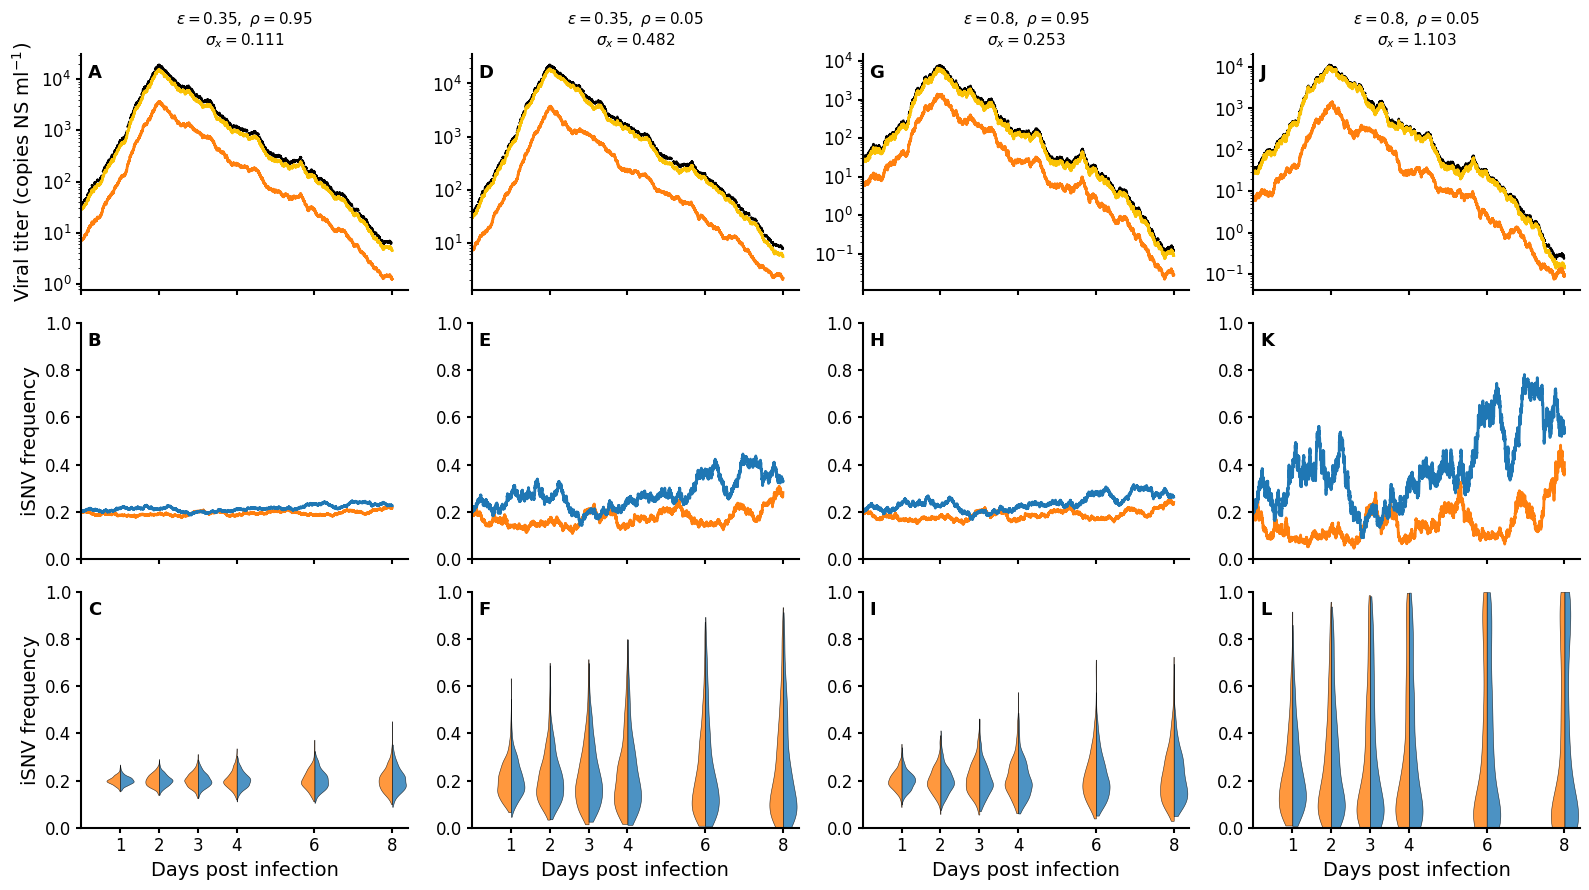

In [ ]:
"""
Figure 2 (combined-frequency + violin version)
==============================================

Row 1 : viral titers  V_total (dashed), V1, V2   - single trajectory (as before)
Row 2 : iSNV frequency - the piecewise-exponential trajectory (f2_A) and the
        Brownian-motion trajectory (f2_bm) OVERLAID on one panel
        (i.e. the old row 2 and row 3 plotted together)
Row 3 : split violin plots of f2 across many simulations at selected days,
        piecewise-exp (left half) vs Brownian-motion (right half)

Rows 1-2 use the original (single-seed) simulators. Row 3 uses vectorised
ensemble re-implementations of the same SDE dynamics (identical drift/noise
structure) to summarise the spread across N_SIMS replicates.
"""

import string

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# Original single-trajectory simulators (unchanged)
# ============================================================
def simulate_two_strain_EM_multivariate(t, V10, V20, r, c, tau, epsilon, rho,
                                        seed=None):
    t = np.asarray(t, dtype=float)
    if len(t) < 2:
        raise ValueError("t must contain at least two time points.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if V10 < 0 or V20 < 0:
        raise ValueError("V10 and V20 must be positive.")
    rng = np.random.default_rng(seed)
    n = len(t)
    V1_A = np.empty(n, dtype=float)
    V2_A = np.empty(n, dtype=float)
    V1_A[0], V2_A[0] = float(V10), float(V20)
    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        if dt <= 0:
            raise ValueError("t must be strictly increasing.")
        mu = r if t[k] < tau else -c
        cov = dt * np.array([[1.0, rho], [rho, 1.0]], dtype=float)
        dW1, dW2 = rng.multivariate_normal(mean=[0.0, 0.0], cov=cov)
        V1_A[k + 1] = V1_A[k] + mu * V1_A[k] * dt + epsilon * V1_A[k] * dW1
        V2_A[k + 1] = V2_A[k] + mu * V2_A[k] * dt + epsilon * V2_A[k] * dW2
    f2_A = V2_A / (V1_A + V2_A)
    return (V1_A, V2_A, f2_A)


def simulate_isnv_frequency_bm(t, f2_0, epsilon=0.2, rho=0.1, seed=None,
                              return_X=False):
    t = np.asarray(t, dtype=float)
    if t.size < 2:
        raise ValueError("t must contain at least two time points.")
    if np.any(np.diff(t) <= 0):
        raise ValueError("t must be strictly increasing.")
    if not (0.0 < f2_0 < 1.0):
        raise ValueError("f2_0 must be strictly between 0 and 1.")
    if not (-1.0 <= rho <= 1.0):
        raise ValueError("rho must be in [-1, 1].")
    if epsilon < 0:
        raise ValueError("epsilon must be nonnegative.")
    rng = np.random.default_rng(seed)
    X0 = np.log(f2_0 / (1.0 - f2_0))
    sigma_X = epsilon * np.sqrt(2.0 * (1.0 - rho))
    n = t.size
    X = np.empty(n, dtype=float)
    X[0] = X0
    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        dB = rng.normal(loc=0.0, scale=np.sqrt(dt))
        X[k + 1] = X[k] + sigma_X * dB
    f2 = 1.0 / (1.0 + np.exp(-X))
    if return_X:
        return f2, X
    return f2


# ============================================================
# Vectorised ensemble simulators (for the violin row only)
# ============================================================
def ensemble_piecewise_exp(t, V10, V20, r, c, tau, epsilon, rho, n_sims,
                           seed=None):
    """Same dynamics as simulate_two_strain_EM_multivariate, vectorised over
    n_sims replicates. Returns f2 of shape (len(t), n_sims)."""
    t = np.asarray(t, dtype=float)
    n = t.size
    rng = np.random.default_rng(seed)
    V1 = np.empty((n, n_sims), dtype=float)
    V2 = np.empty((n, n_sims), dtype=float)
    V1[0] = V10
    V2[0] = V20
    sqrt_1mrho2 = np.sqrt(max(0.0, 1.0 - rho * rho))
    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        mu = r if t[k] < tau else -c
        sdt = np.sqrt(dt)
        z1 = rng.standard_normal(n_sims)
        z2 = rng.standard_normal(n_sims)
        dW1 = sdt * z1
        dW2 = sdt * (rho * z1 + sqrt_1mrho2 * z2)
        V1[k + 1] = V1[k] + mu * V1[k] * dt + epsilon * V1[k] * dW1
        V2[k + 1] = V2[k] + mu * V2[k] * dt + epsilon * V2[k] * dW2
    return V2 / (V1 + V2)


def ensemble_bm(t, f2_0, epsilon, rho, n_sims, seed=None):
    """Same dynamics as simulate_isnv_frequency_bm, vectorised over n_sims.
    Returns f2 of shape (len(t), n_sims)."""
    t = np.asarray(t, dtype=float)
    n = t.size
    rng = np.random.default_rng(seed)
    X0 = np.log(f2_0 / (1.0 - f2_0))
    sigma_X = epsilon * np.sqrt(2.0 * (1.0 - rho))
    X = np.empty((n, n_sims), dtype=float)
    X[0] = X0
    for k in range(n - 1):
        dt = t[k + 1] - t[k]
        dB = np.sqrt(dt) * rng.standard_normal(n_sims)
        X[k + 1] = X[k] + sigma_X * dB
    return 1.0 / (1.0 + np.exp(-X))


# ============================================================
# Split-violin helper
# ============================================================
def half_violin(ax, data, pos, side, color, width=0.7):
    parts = ax.violinplot([data], positions=[pos], widths=width,
                          showextrema=False)
    body = parts["bodies"][0]
    verts = body.get_paths()[0].vertices
    if side == "left":
        verts[:, 0] = np.clip(verts[:, 0], -np.inf, pos)
    else:
        verts[:, 0] = np.clip(verts[:, 0], pos, np.inf)
    body.set_facecolor(color)
    body.set_edgecolor("black")
    body.set_linewidth(0.4)
    body.set_alpha(0.8)
    med = np.median(data)
    #if side == "left":
    #    ax.plot([pos - width * 0.28, pos], [med, med], color="black", lw=1.0)
    #else:
    #    ax.plot([pos, pos + width * 0.28], [med, med], color="black", lw=1.0)


# ============================================================
# Figure 2 generator
# ============================================================
def make_figure2(seed_piecewise=123, seed_bm=123, n_sims=500,
                 snapshot_days=(1, 2, 3, 4, 6, 8)):
    t_eval = np.linspace(0, 8, 8001)

    tau_hat = 1.9966
    r_hat = 3.3589
    c_hat = 1.1132
    logV0 = 2.9290

    V10 = np.exp(logV0) * 1.6
    V20 = np.exp(logV0) * 0.4
    f2_0 = 0.2

    scenarios = [
        (0.35, 0.95),
        (0.35, 0.05),
        (0.8, 0.95),
        (0.8, 0.05),
    ]

    snap_idx = [int(np.argmin(np.abs(t_eval - d))) for d in snapshot_days]

    col_pw = "tab:orange"   # piecewise exponential
    col_bm = "tab:blue"     # Brownian motion

    fig, axes = plt.subplots(3, 4, figsize=(16, 9))

    panel_labels = list(string.ascii_uppercase)
    label_counter = 0

    label_font = 14
    tick_font = 12
    panel_font = 13
    label_weight = 21

    # common x range; small right pad so the day-8 violin half isn't clipped
    xlim = (0.0, 8.4)

    for j, (epsilon, rho) in enumerate(scenarios):
        # --- single trajectories (rows 1-2) ---
        V1_A, V2_A, f2_A = simulate_two_strain_EM_multivariate(
            t=t_eval, V10=V10, V20=V20, r=r_hat, c=c_hat, tau=tau_hat,
            epsilon=epsilon, rho=rho, seed=seed_piecewise
        )
        V_total_A = V1_A + V2_A
        f2_bm = simulate_isnv_frequency_bm(
            t=t_eval, f2_0=f2_0, epsilon=epsilon, rho=rho, seed=seed_bm
        )

        # --- ensembles (row 3 only) ---
        f2_pw_ens = ensemble_piecewise_exp(
            t_eval, V10, V20, r_hat, c_hat, tau_hat, epsilon, rho,
            n_sims, seed=seed_piecewise + j
        )
        f2_bm_ens = ensemble_bm(
            t_eval, f2_0, epsilon, rho, n_sims, seed=seed_bm + j
        )
        f2_pw_ens = np.clip(f2_pw_ens, 0.0, 1.0)

        sigma_x = epsilon * np.sqrt(2.0 * (1.0 - rho))

        # ---------------------------------------------------------
        # Row 1: viral titers
        # ---------------------------------------------------------
        ax = axes[0, j]
        ax.plot(t_eval, V_total_A, color="black", lw=1.8, ls="--",
                label=r"$V_{\mathrm{total}}$")
        ax.plot(t_eval, V1_A, color="#FAC205", lw=2.0, label=r"$V_1$")
        ax.plot(t_eval, V2_A, color="tab:orange", lw=2.0, label=r"$V_2$")
        ax.set_title(rf"$\epsilon={epsilon},\ \rho={rho}$" "\n"
                     rf"$\sigma_x={sigma_x:.3f}$", fontsize=11)
        if j == 0:
            ax.set_ylabel(r"Viral titer (copies NS ml$^{-1}$)",
                          fontsize=label_font, fontweight=label_weight)
        ax.text(0.02, 0.96, panel_labels[label_counter], transform=ax.transAxes,
                ha="left", va="top", fontsize=panel_font, fontweight="bold")
        label_counter += 1
        ax.set_yscale("log")
        ax.set_xlim(*xlim)
        ax.tick_params(axis="both", labelsize=tick_font, width=1.5)
        plt.setp(ax.get_xticklabels(), visible=False)
        for tick in ax.get_yticklabels():
            tick.set_fontweight(label_weight)

        # ---------------------------------------------------------
        # Row 2: piecewise-exp and BM frequency trajectories together
        # ---------------------------------------------------------
        ax = axes[1, j]
        ax.plot(t_eval, f2_A, lw=2.0, color=col_pw, label="Piecewise exp")
        ax.plot(t_eval, f2_bm, lw=2.0, color=col_bm, label="Brownian motion")
        ax.set_ylim(0, 1)
        ax.set_xlim(*xlim)
        if j == 0:
            ax.set_ylabel("iSNV frequency", fontsize=label_font,
                          fontweight=label_weight)
        ax.text(0.02, 0.96, panel_labels[label_counter], transform=ax.transAxes,
                ha="left", va="top", fontsize=panel_font, fontweight="bold")
        label_counter += 1
        ax.tick_params(axis="both", labelsize=tick_font, width=1.5)
        plt.setp(ax.get_xticklabels(), visible=False)
        for tick in ax.get_yticklabels():
            tick.set_fontweight(label_weight)

        # ---------------------------------------------------------
        # Row 3: split violins across many simulations
        # ---------------------------------------------------------
        ax = axes[2, j]
        for d, idx in zip(snapshot_days, snap_idx):
            half_violin(ax, f2_pw_ens[idx], d, side="left", color=col_pw)
            half_violin(ax, f2_bm_ens[idx], d, side="right", color=col_bm)
        ax.set_ylim(0, 1)
        ax.set_xlim(*xlim)
        ax.set_xticks(list(snapshot_days))
        if j == 0:
            ax.set_ylabel(f"iSNV frequency",
                          fontsize=label_font, fontweight=label_weight)
        ax.set_xlabel("Days post infection", fontsize=label_font,
                      fontweight=label_weight)
        ax.text(0.02, 0.96, panel_labels[label_counter], transform=ax.transAxes,
                ha="left", va="top", fontsize=panel_font, fontweight="bold")
        label_counter += 1
        ax.tick_params(axis="both", labelsize=tick_font, width=1.5)
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight(label_weight)

    # cosmetic cleanup
    for i in range(3):
        for j in range(4):
            axes[i, j].spines["top"].set_visible(False)
            axes[i, j].spines["right"].set_visible(False)
            axes[i, j].spines["left"].set_linewidth(1.5)
            axes[i, j].spines["bottom"].set_linewidth(1.5)

    plt.tight_layout()
    return fig


# ============================================================
# Run
# ============================================================
if __name__ == "__main__":
    make_figure2(seed_piecewise=123, seed_bm=123, n_sims=500)
    print("done")

### Figure 3

In [23]:
dataset_sigma_06_small = np.load("data/mock_datasets_sigma_06_small.npy")
dataset_sigma_10_small = np.load("data/mock_datasets_sigma_10_small.npy")
dataset_sigma_14_small = np.load("data/mock_datasets_sigma_14_small.npy")
X_samples_all = np.load("data/X_samples_all.npy", allow_pickle=True).item()

t_start = 0.0
t_end   = 10.0
dt      = 0.001
t       = np.arange(t_start, t_end + dt, dt)


In [24]:
def bm_loglik_sigma_x_censored_freqspace(
    X_pairs, T, sigma_x,
    f_threshold=0.02,
    x_threshold=None
):
    """
    Frequency-space BM log-likelihood for sigma_x with three-interval
    censoring, where the underlying process is BM in X = logit(f).

    Uncensored:
        log p_F(fT | f0) = log p_X(XT | X0) + log |dX/dfT|
    Left-censored  (XT < lower): log P(XT < lower | X0)   [invariant to f-space]
    Right-censored (XT > upper): log P(XT > upper | X0)   [invariant to f-space]

    X_pairs are still supplied in X-space (logit frequencies).
    """
    X_pairs = np.asarray(X_pairs, dtype=float)
    if X_pairs.ndim != 2 or X_pairs.shape[1] != 2:
        raise ValueError("X_pairs must have shape (n, 2).")
    if T <= 0:
        raise ValueError("T must be positive.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_threshold is None:
        if not (0.0 < f_threshold < 1.0):
            raise ValueError("f_threshold must be in (0,1).")
        x_threshold = float(logit_transform(f_threshold))

    X0 = X_pairs[:, 0]
    XT = X_pairs[:, 1]

    sd = sigma_x * math.sqrt(T)

    lower = x_threshold
    upper = - x_threshold          # <-- see note below
    if not (lower < upper):
        raise ValueError("Need x_threshold < 0.5 for three-interval censoring.")

    left_cens  = XT < lower
    right_cens = XT > upper
    mid_uncens = (~left_cens) & (~right_cens)

    loglik = 0.0

    # --------------------------------------------------------
    # Uncensored: Normal density in X + logit Jacobian to f-space
    # --------------------------------------------------------
    if np.any(mid_uncens):
        x0_m = X0[mid_uncens]
        xt_m = XT[mid_uncens]

        z = (xt_m - x0_m) / sd
        log_density_X = (
            -0.5 * z**2
            - np.log(sd)
            - 0.5 * np.log(2 * np.pi)
        )

        # dX/dfT = 1 / (fT (1 - fT))  ->  log|dX/dfT| = -log fT - log(1 - fT)
        fT_m = 1.0 / (1.0 + np.exp(-xt_m))
        fT_m = np.clip(fT_m, 1e-12, 1 - 1e-12)
        log_jacobian = -np.log(fT_m) - np.log1p(-fT_m)

        loglik += np.sum(log_density_X + log_jacobian)

    # --------------------------------------------------------
    # Censored contributions are probabilities -> unchanged
    # --------------------------------------------------------
    if np.any(left_cens):
        zL = (lower - X0[left_cens]) / sd
        loglik += np.sum(norm.logcdf(zL))


    if np.any(right_cens):
        zU = (upper - X0[right_cens]) / sd
        loglik += np.sum(norm.logsf(zU))

    return float(loglik)

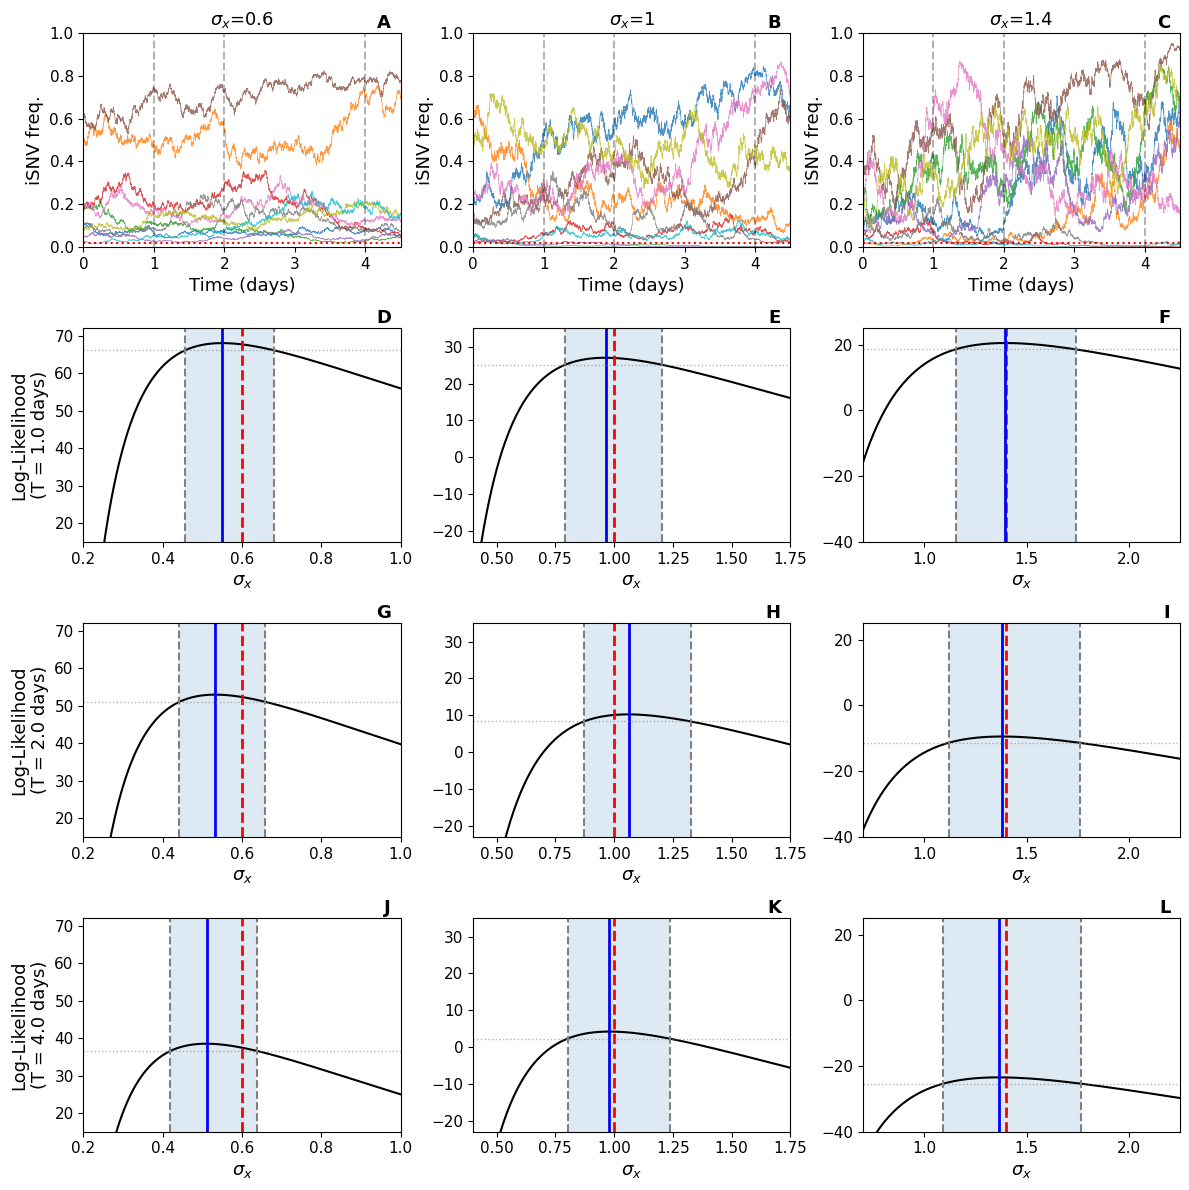

In [25]:
cut = -0.5 * 3.841458820694124  # ~= -1.9207294103

sigma_map = {
    "sigma_06": 0.6,
    "sigma_10": 1,
    "sigma_14": 1.4,
}

datasets_map = {
    "sigma_06": dataset_sigma_06_small,
    "sigma_10": dataset_sigma_10_small,
    "sigma_14": dataset_sigma_14_small,
}

T_hours_list = [24, 48, 96]
T_days_map = {h: h / 24.0 for h in T_hours_list}

# --------------------------------------------------
# Font settings
# --------------------------------------------------
label_font = 13
tick_font = 11
panel_font = 13
title_font = 13

# --------------------------------------------------
# Create 4x3 panel
# --------------------------------------------------
fig, axes = plt.subplots(4, 3, figsize=(12, 12))

panel_labels = list(string.ascii_uppercase[:18])
panel_counter = 0

# --------------------------------------------------
# ROW 1 — Example trajectories
# --------------------------------------------------
for col, (short, true_sigma) in enumerate(sigma_map.items()):

    dataset = datasets_map[short]
    ax = axes[0, col]

    for i in range(10):
        ax.plot(t, dataset[i], alpha=0.8, linewidth=0.5)

    ax.set_title(
        rf"$\sigma_x$={true_sigma}",
        fontsize=title_font,
    )

    ax.set_ylabel(
        r"iSNV freq.",
        fontsize=label_font,
    )

    ax.set_xlabel(
        "Time (days)",
        fontsize=label_font,
    )

    ax.set_ylim(0, 1)
    ax.set_xlim(0, 4.5)

    ax.axhline(
        0.02,
        color="red",
        linestyle=":",
        label="Variant call threshold"
    )

    for T_day in T_days_map.values():
        T_hour = T_day * 24
        ax.axvline(
            T_day,
            color="black",
            linestyle="--",
            alpha=0.3,
            label=f"T = {int(T_hour)} h"
        )

    ax.text(
        0.97, 1.09,
        panel_labels[panel_counter],
        transform=ax.transAxes,
        fontsize=panel_font,
        fontweight="bold",
        ha="right",
        va="top"
    )

    panel_counter += 1


# --------------------------------------------------
# Likelihood plotting function
# --------------------------------------------------
def plot_ll_on_axis(ax, X_pairs, T_days, true_sigma):

    sigma_grid = np.linspace(0.05, 2.0 * true_sigma, 400)

    ll = np.array([
        bm_loglik_sigma_x_censored_freqspace(X_pairs, T=T_days, sigma_x=s)
        for s in sigma_grid
    ])

    ll_centered = ll
    sigma_hat = sigma_grid[np.argmax(ll)]

    # Likelihood curve
    ax.plot(
        sigma_grid,
        ll_centered,
        color="black",
        linewidth=1.5
    )

    # True sigma
    ax.axvline(
        true_sigma,
        color="red",
        linestyle="--",
        linewidth=2,
        label=rf"True $\sigma_x$ = {true_sigma:.2f}"
    )

    # MLE sigma
    ax.axvline(
        sigma_hat,
        color="blue",
        linestyle="-",
        linewidth=2,
        label=rf"MLE $\hat{{\sigma}}_x$ = {sigma_hat:.3f}"
    )

    # -----------------------------
    # 95% CI via log-likelihood ratio, chi-square df = 1
    # -----------------------------
    chi2_95_df1 = 3.841458820694124
    cut = -0.5 * chi2_95_df1 + np.max(ll)

    i_hat = int(np.argmin(np.abs(sigma_grid - sigma_hat)))

    # Left CI bound
    left_idx_candidates = np.where(ll_centered[:i_hat + 1] < cut)[0]

    if len(left_idx_candidates) == 0:
        ci_low = sigma_grid[0]
    else:
        i1 = left_idx_candidates[-1]
        i2 = min(i1 + 1, i_hat)

        x1, x2 = sigma_grid[i1], sigma_grid[i2]
        y1, y2 = ll_centered[i1], ll_centered[i2]

        ci_low = (
            x1 + (cut - y1) * (x2 - x1) / (y2 - y1)
            if y2 != y1
            else x1
        )

    # Right CI bound
    right_idx_candidates = np.where(ll_centered[i_hat:] < cut)[0]

    if len(right_idx_candidates) == 0:
        ci_high = sigma_grid[-1]
    else:
        j2 = i_hat + right_idx_candidates[0]
        j1 = max(j2 - 1, i_hat)

        x1, x2 = sigma_grid[j1], sigma_grid[j2]
        y1, y2 = ll_centered[j1], ll_centered[j2]

        ci_high = (
            x1 + (cut - y1) * (x2 - x1) / (y2 - y1)
            if y2 != y1
            else x2
        )

    # Cutoff line
    ax.axhline(
        cut,
        color="gray",
        linestyle=":",
        linewidth=1,
        alpha=0.6
    )

    # CI region and boundary lines
    ax.axvspan(ci_low, ci_high, alpha=0.15)

    ax.axvline(
        ci_low,
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=rf"95% CI = [{ci_low:.3f}, {ci_high:.3f}]"
    )

    ax.axvline(
        ci_high,
        color="gray",
        linestyle="--",
        linewidth=1.5
    )

    ax.set_xlim(0, 3.0 * true_sigma)

    ax.set_xlabel(
        r"$\sigma_x$",
        fontsize=label_font,
    )


# --------------------------------------------------
# ROWS 2–4 — Likelihood panels
# --------------------------------------------------
for row_idx, T_hours in enumerate(T_hours_list, start=1):

    for col, (short, true_sigma) in enumerate(sigma_map.items()):

        ax = axes[row_idx, col]

        X_pairs = X_samples_all[short][T_hours]
        T_days = T_days_map[T_hours]

        plot_ll_on_axis(ax, X_pairs, T_days, true_sigma)

        if col == 1:
            ax.set_xlim(0.4, 1.75)
            ax.set_ylim(-23, 35)

        if col == 2:
            ax.set_ylim(-40, 25)
            ax.set_xlim(0.70, 2.25)

        if col == 0:
            ax.set_ylabel(
                f"Log-Likelihood\n(T = {T_days} days)",
                fontsize=label_font,
            )
            ax.set_ylim(15, 72)
            ax.set_xlim(0.2, 1)

        ax.text(
            0.97, 1.09,
            panel_labels[panel_counter],
            transform=ax.transAxes,
            fontsize=panel_font,
            fontweight="bold",
            ha="right",
            va="top"
        )

        panel_counter += 1


# --------------------------------------------------
# Apply tick font size and bold tick labels globally
# --------------------------------------------------
for ax in axes.flat:
    ax.tick_params(
        axis="both",
        labelsize=tick_font
    )




plt.tight_layout()
plt.show()

### Figure 4

In [27]:
dataset_sigma_06_nu400 = np.load("data/dataset_sigma_06_nu400.npy")
dataset_sigma_10_nu400 = np.load("data/dataset_sigma_10_nu400.npy")
dataset_sigma_14_nu400 = np.load("data/dataset_sigma_14_nu400.npy")

dataset_sigma_06_measnoise = np.load("data/dataset_sigma_06_nu40.npy")
dataset_sigma_10_measnoise = np.load("data/dataset_sigma_10_nu40.npy")
dataset_sigma_14_measnoise = np.load("data/dataset_sigma_14_nu40.npy")

base = "heatmap_results/"

d = np.load(base + "mock_sigma_06_logL_fitexp_nu400.npz")
logL_06_nu400_fitexp, F2_06_nu400 = d["logL"], float(d["f2_mean"])

d = np.load(base + "mock_sigma_10_logL_fitexp_nu400.npz")
logL_10_nu400_fitexp, F2_10_nu400 = d["logL"], float(d["f2_mean"])

d = np.load(base + "mock_sigma_14_logL_fitexp_nu400.npz")
logL_14_nu400_fitexp, F2_14_nu400 = d["logL"], float(d["f2_mean"])

d = np.load(base + "mock_sigma_06_logL_fitexp_nu10.npz")
logL_06_nu10_fitexp, F2_06_nu10 = d["logL"], float(d["f2_mean"])

d = np.load(base + "mock_sigma_10_logL_fitexp_nu10.npz")
logL_10_nu10_fitexp, F2_10_nu10 = d["logL"], float(d["f2_mean"])

d = np.load(base + "mock_sigma_14_logL_fitexp_nu10.npz")
logL_14_nu10_fitexp, F2_14_nu10 = d["logL"], float(d["f2_mean"])

datasets_heatmap_exp = [
    [   # heatmap row 0 — true nu = 400
        (r"$\sigma_x = 0.6$", 0.6, logL_06_nu400_fitexp, F2_06_nu400),
        (r"$\sigma_x = 1.0$", 1.0, logL_10_nu400_fitexp, F2_10_nu400),
        (r"$\sigma_x = 1.4$", 1.4, logL_14_nu400_fitexp, F2_14_nu400),
    ],
    [   # heatmap row 1 — true nu = 10
        (r"$\sigma_x = 0.6$", 0.6, logL_06_nu10_fitexp, F2_06_nu10),
        (r"$\sigma_x = 1.0$", 1.0, logL_10_nu10_fitexp, F2_10_nu10),
        (r"$\sigma_x = 1.4$", 1.4, logL_14_nu10_fitexp, F2_14_nu10),
    ],
]

sigma_grid = np.linspace(0.05, 2.2, 60)
nu_grid    = np.logspace(-1, 4, 60)

T_days     = 24 / 24.0   # 24 h expressed in days


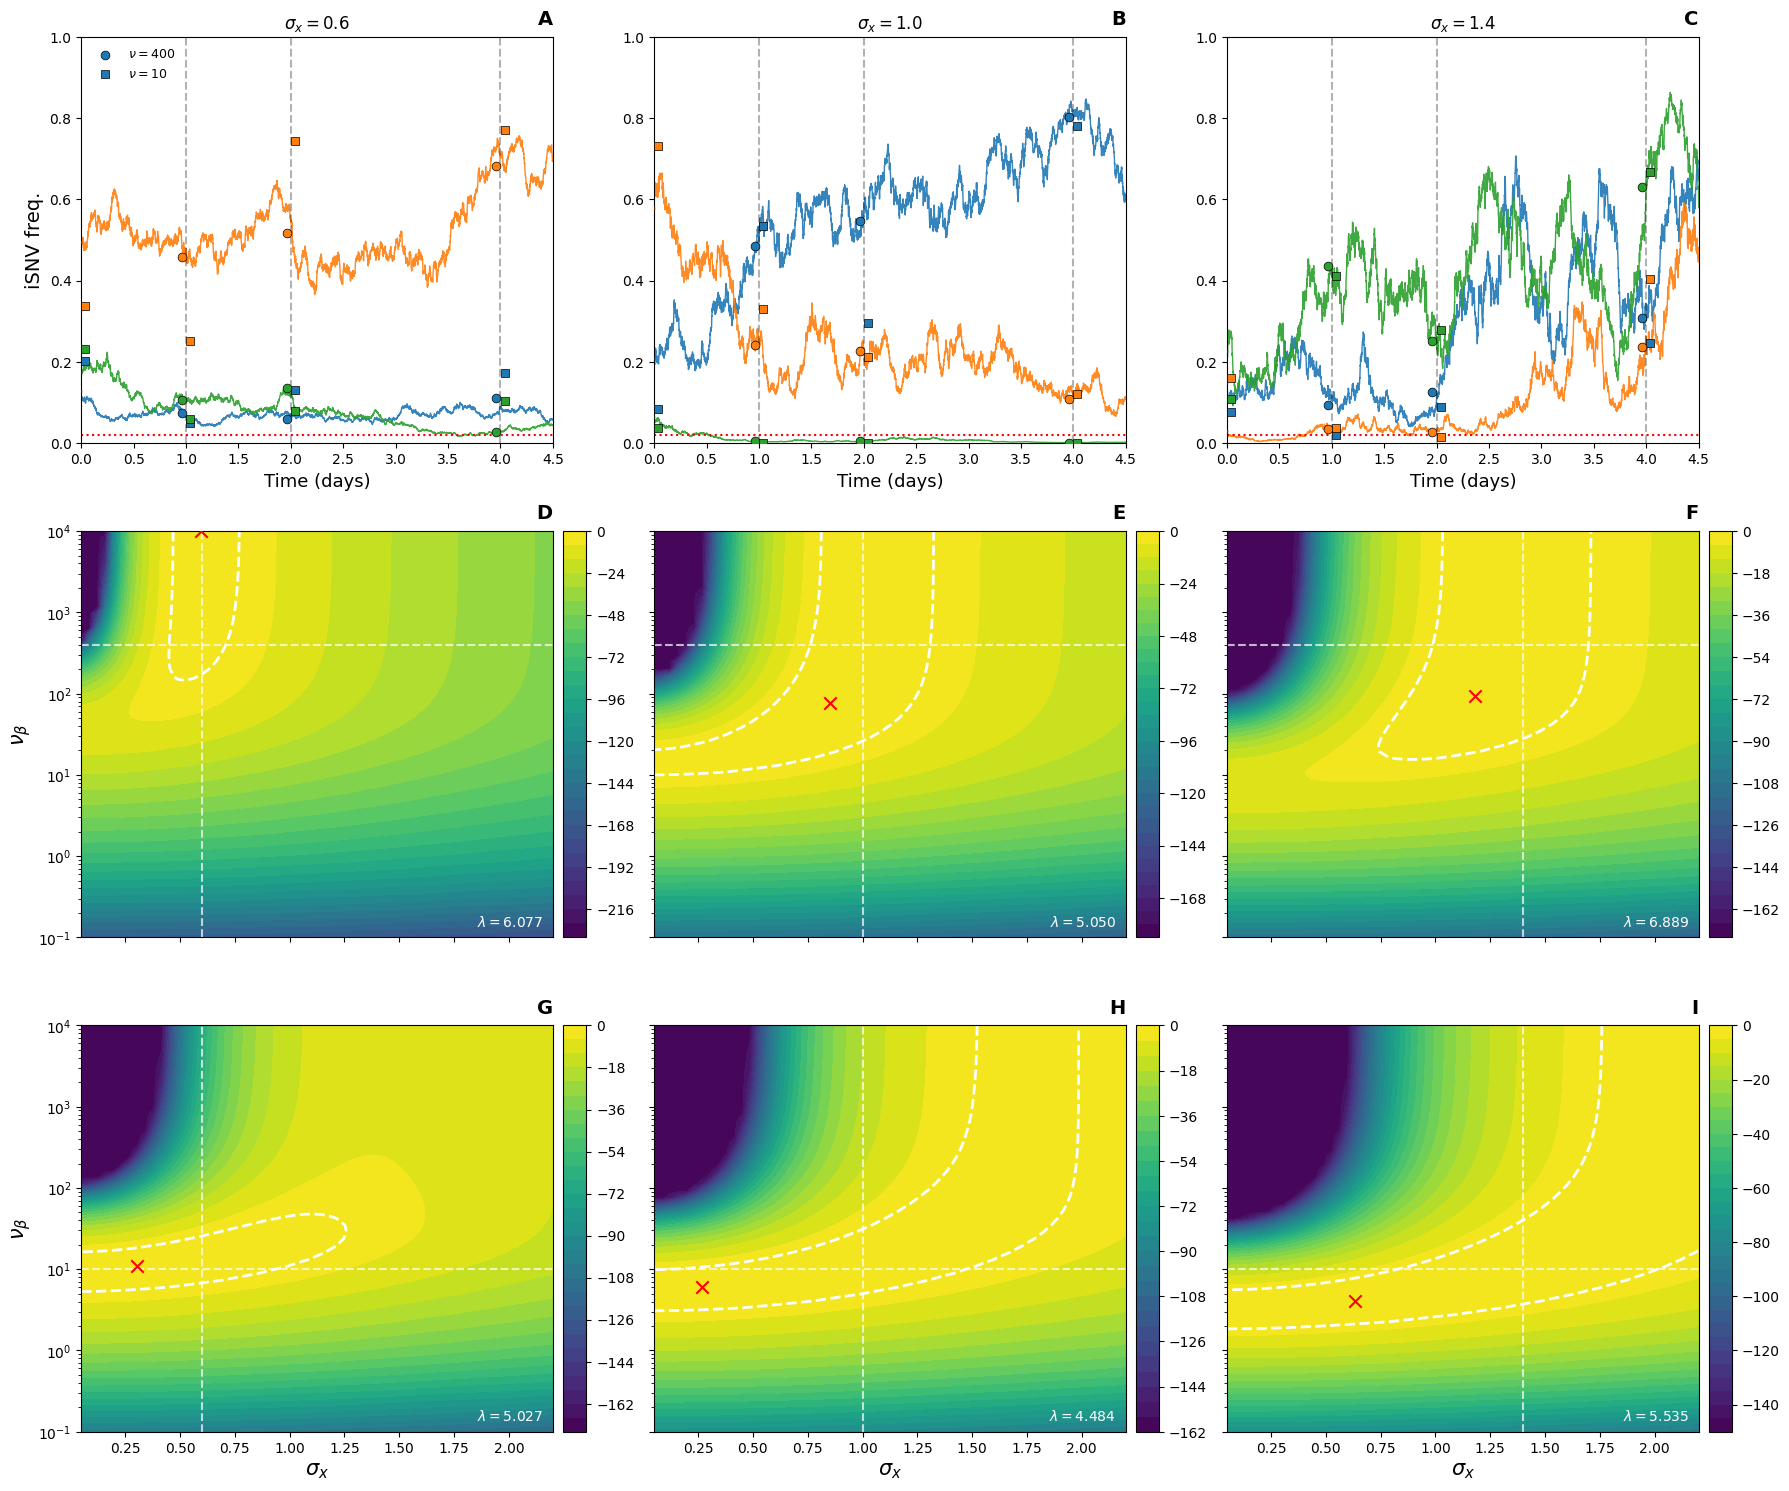

In [28]:
from scipy import stats
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ---- Trajectory-row layout ----
T_hours_list = [24, 48, 96]
T_days_map   = {h: h / 24.0 for h in T_hours_list}
obs_days     = [0.0] + list(T_days_map.values())          # [0, 1, 2, 4] days
obs_i        = [int(np.argmin(np.abs(t - d))) for d in obs_days]

n_examples   = 3
traj_colors  = plt.cm.tab10(np.linspace(0, 1, 10))
jitter       = 0.04   # day offset so circles and squares don't overlap

# ---- Heatmap layout ----
threshold_95 = -stats.chi2.ppf(0.95, df=2) / 2

clean_map = {
    0.6: dataset_sigma_06_small,
    1.0: dataset_sigma_10_small,
    1.4: dataset_sigma_14_small,
}
noisy_400 = {
    0.6: dataset_sigma_06_nu400,
    1.0: dataset_sigma_10_nu400,
    1.4: dataset_sigma_14_nu400,
}
noisy_10 = {
    0.6: dataset_sigma_06_measnoise,
    1.0: dataset_sigma_10_measnoise,
    1.4: dataset_sigma_14_measnoise,
}

datasets_heatmap = [
    [   # heatmap row 0 — true nu = 400
        (r"$\sigma_x = 0.6$", 0.6, logL_06_nu400_fitexp, F2_06_nu400),
        (r"$\sigma_x = 1.0$", 1.0, logL_10_nu400_fitexp, F2_10_nu400),
        (r"$\sigma_x = 1.4$", 1.4, logL_14_nu400_fitexp, F2_14_nu400),
    ],
    [   # heatmap row 1 — true nu = 10
        (r"$\sigma_x = 0.6$", 0.6, logL_06_nu10_fitexp, F2_06_nu10),
        (r"$\sigma_x = 1.0$", 1.0, logL_10_nu10_fitexp, F2_10_nu10),
        (r"$\sigma_x = 1.4$", 1.4, logL_14_nu10_fitexp, F2_14_nu10),
    ],
]

hline_nu     = [400, 10]
panel_labels = [['A', 'B', 'C'], ['D', 'E', 'F'], ['G', 'H', 'I']]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# --------------------------------------------------
# Row 0 — example trajectories
# --------------------------------------------------
for col, true_sigma in enumerate([0.6, 1.0, 1.4]):
    ax = axes[0, col]
    clean = clean_map[true_sigma]

    for k in range(n_examples):
        c = traj_colors[k]
        ax.plot(t, clean[k], color=c, alpha=0.9, linewidth=1.0)

        # nu=400 observations — circles, shifted left
        ax.scatter(
            [t[j] - jitter for j in obs_i],
            [noisy_400[true_sigma][k, j] for j in obs_i],
            color=c, edgecolor="black", linewidth=0.5,
            marker="o", s=40, zorder=5,
            label=r"$\nu = 400$" if (k == 0 and col == 0) else None,
        )
        # nu=10 observations — squares, shifted right
        ax.scatter(
            [t[j] + jitter for j in obs_i],
            [noisy_10[true_sigma][k, j] for j in obs_i],
            color=c, edgecolor="black", linewidth=0.5,
            marker="s", s=40, zorder=5,
            label=r"$\nu = 10$" if (k == 0 and col == 0) else None,
        )

    ax.set_title(rf"$\sigma_x = {true_sigma}$")
    ax.set_xlabel("Time (days)", fontsize=label_font)
    ax.set_xlim(0, 4.5)
    ax.set_ylim(0, 1)
    ax.axhline(0.02, color="red", linestyle=":")
    for T_day in T_days_map.values():
        ax.axvline(T_day, color="black", linestyle="--", alpha=0.3)
    if col == 0:
        ax.set_ylabel("iSNV freq.", fontsize = 14)
        ax.legend(fontsize=9, loc="upper left", frameon=False)

    # invisible colorbar slot keeps column widths aligned with rows below
    cax = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1)
    cax.set_axis_off()

# --------------------------------------------------
# Rows 1–2 — heatmaps
# --------------------------------------------------
for row in range(2):
    for col in range(3):
        ax = axes[row + 1, col]
        _title, true_sigma, logL_raw, F2= datasets_heatmap[row][col]

        logL = np.copy(logL_raw)
        logL[logL < -160] = -160
        logL_centered = logL - np.max(logL)

        max_idx   = np.unravel_index(np.argmax(logL), logL.shape)
        sigma_hat = sigma_grid[max_idx[0]]
        nu_hat    = nu_grid[max_idx[1]]

        cs = ax.contourf(sigma_grid, nu_grid, logL_centered.T, levels=30, cmap="viridis")

        if not np.all(logL_centered == 0):
            ax.contour(sigma_grid, nu_grid, logL_centered.T,
                       levels=[threshold_95], colors="white",
                       linestyles="dashed", linewidths=2)

        ax.axhline(hline_nu[row], color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.axvline(true_sigma,    color="white", linestyle="--", linewidth=1.5, alpha=0.7)
        ax.scatter(sigma_hat, nu_hat, color="red", marker="x", s=80, zorder=10,
                   label=f"MLE: σ={sigma_hat:.2f}, ν={nu_hat:.1f}")
        ax.text(0.98, 0.02, fr"$\lambda={1/F2:.3f}$", color="white", fontsize=10,
                ha="right", va="bottom", transform=ax.transAxes)
        ax.set_yscale("log")
        ax.set_xlim(sigma_grid[0], sigma_grid[-1])
        ax.set_ylim(nu_grid[0], nu_grid[-1])

        if row == 1:
            ax.set_xlabel(r"$\sigma_x$", fontsize=15)
        else:
            ax.set_xticklabels([])
        if col == 0:
            ax.set_ylabel(r"$\nu_{\beta}$", fontsize=15)
        else:
            ax.set_yticklabels([])

        cax = make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(cs, cax=cax)
        # cbar.set_label("Log-likelihood")

# --------------------------------------------------
# Panel labels A–I
# --------------------------------------------------
for r in range(3):
    for c in range(3):
        axes[r, c].text(
            1.0, 1.02, panel_labels[r][c],
            transform=axes[r, c].transAxes,
            fontsize=14, fontweight="bold", va="bottom", ha="right",
        )

plt.tight_layout()
plt.show()


### Figure 5 

In [29]:
def _normal_logpdf(x, mean, var):
    # log N(x; mean, var)
    return -0.5 * (math.log(2.0 * math.pi * var) + ((x - mean) ** 2) / var)

def bm_loglik_sigma_x_censored(
    X_pairs, T, sigma_x,
    f_threshold=0.02,
    x_threshold=None
):
    """
    Brownian motion log-likelihood for sigma_x with left-censoring on XT.

    If XT is observed (>= x_threshold): use Normal PDF.
    If XT is censored (<  x_threshold): use Normal CDF P(XT < x_threshold | X0).

    Parameters
    ----------
    X_pairs : array, shape (n, 2)
        Column 0 = X0, Column 1 = XT (or the reported XT even if it's below threshold).
    T : float
    sigma_x : float > 0
    f_threshold : float
        Variant calling threshold in frequency space (default 0.02).
    x_threshold : float or None
        If provided, overrides f_threshold and is interpreted directly in X-space.
    """
    X_pairs = np.asarray(X_pairs, dtype=float)
    if X_pairs.ndim != 2 or X_pairs.shape[1] != 2:
        raise ValueError("X_pairs must have shape (n, 2).")
    if T <= 0:
        raise ValueError("T must be positive.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_threshold is None:
        if not (0.0 < f_threshold < 1.0):
            raise ValueError("f_threshold must be in (0,1).")
        x_threshold = float(logit_transform(f_threshold))

    X0 = X_pairs[:, 0]
    XT = X_pairs[:, 1]

    var = (sigma_x ** 2) * T
    sd = sigma_x * math.sqrt(T)



    lower = x_threshold
    upper = - x_threshold
    if not (lower < upper):
        raise ValueError("Need x_threshold < 0.5 for three-interval censoring.")

    # Censoring rule: if the second value is below X-threshold, treat as left-censored
    left_cens  = XT < lower
    right_cens = XT > upper
    mid_uncens = (~left_cens) & (~right_cens)

    loglik = 0.0

    if np.any(mid_uncens):
        for x0, xt in zip(X0[mid_uncens], XT[mid_uncens]):
            loglik += _normal_logpdf(xt, mean=x0, var=var)

    if np.any(left_cens):
        zL = (lower - X0[left_cens]) / sd
        loglik += np.sum(norm.logcdf(zL))

    if np.any(right_cens):
        zU = (upper - X0[right_cens]) / sd
        loglik += np.sum(norm.logsf(zU))

    return float(loglik)

In [30]:
def bm_loglik_sigma_x_censored_varyingT(
    X0, XT, T_arr, sigma_x,
    f_threshold=0.02, x_threshold=None
):
    """
    Sum loglik across observations with per-observation T.
    X0, XT are in X-space already (logit frequencies).
    """
    X0 = np.asarray(X0, float)
    XT = np.asarray(XT, float)
    T_arr = np.asarray(T_arr, float)

    if not (len(X0) == len(XT) == len(T_arr)):
        raise ValueError("X0, XT, T_arr must have the same length.")
    if np.any(T_arr <= 0):
        raise ValueError("All T must be > 0.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    # threshold in X-space
    if x_threshold is None:
        x_threshold = float(logit_transform(f_threshold))

    ll = 0.0
    for x0, xt, T in zip(X0, XT, T_arr):
        # call your existing function on a single row by making shape (1,2)
        ll += bm_loglik_sigma_x_censored(
            X_pairs=np.array([[x0, xt]]),
            T=float(T),
            sigma_x=float(sigma_x),
            f_threshold=f_threshold,
            x_threshold=x_threshold
        )
    return float(ll)

from scipy.special import log_ndtr

from scipy.special import log_ndtr

def bm_loglik_sigma_x_censored_varyingT_freqspace(
    X0, XT, T_arr, sigma_x,
    f_lower=0.02, f_upper=0.98,
    x_lower=None, x_upper=None,
):
    """
    Frequency-space likelihood for Brownian motion in X = logit(f),
    with interval censoring at BOTH ends of the frequency scale.

        fT <  f_lower  ->  log P(X_T <  x_lower | X_0)
        fT >  f_upper  ->  log P(X_T >  x_upper | X_0)
        otherwise      ->  log p_X(X_T | X_0) + log |dX/df_T|

    Set f_upper=None to disable upper censoring.
    """
    X0 = np.asarray(X0, float)
    XT = np.asarray(XT, float)
    T_arr = np.asarray(T_arr, float)

    if not (len(X0) == len(XT) == len(T_arr)):
        raise ValueError("X0, XT, T_arr must have the same length.")
    if np.any(T_arr <= 0):
        raise ValueError("All T must be > 0.")
    if sigma_x <= 0:
        raise ValueError("sigma_x must be positive.")

    if x_lower is None:
        x_lower = float(logit_transform(f_lower))
    if x_upper is None and f_upper is not None:
        x_upper = float(logit_transform(f_upper))
    if x_upper is not None and x_upper <= x_lower:
        raise ValueError("upper threshold must exceed lower threshold.")

    sd = sigma_x * np.sqrt(T_arr)

    # strict comparisons on both ends, matching the spectral implementation
    is_lower = XT < x_lower
    is_upper = (np.zeros_like(is_lower) if x_upper is None
                else XT > x_upper)
    is_exact = ~(is_lower | is_upper)

    ll = 0.0

    if np.any(is_exact):
        z = (XT[is_exact] - X0[is_exact]) / sd[is_exact]
        log_density_X = (-0.5 * z**2
                         - np.log(sd[is_exact])
                         - 0.5 * np.log(2 * np.pi))
        fT_e = np.clip(1.0 / (1.0 + np.exp(-XT[is_exact])), 1e-12, 1 - 1e-12)
        log_jacobian = -np.log(fT_e) - np.log1p(-fT_e)
        ll += np.sum(log_density_X + log_jacobian)

    if np.any(is_lower):
        ll += np.sum(log_ndtr((x_lower - X0[is_lower]) / sd[is_lower]))

    if np.any(is_upper):
        ll += np.sum(log_ndtr((X0[is_upper] - x_upper) / sd[is_upper]))

    return float(ll)

def compute_sigma_profile(df2, sigma_grid, f_lower=0.02, f_upper=0.98):
    chi2_95_df1 = 3.841458820694124
    cut = -0.5 * chi2_95_df1

    ll_grid = np.array([
        bm_loglik_sigma_x_censored_varyingT_freqspace(
            X0=df2["X0"].to_numpy(),
            XT=df2["XT"].to_numpy(),
            T_arr=df2["T"].to_numpy(),
            sigma_x=s,
            f_lower=f_lower,
            f_upper=f_upper,
        )
        for s in sigma_grid
    ], dtype=float)

    mle_idx = int(np.argmax(ll_grid))
    sigma_mle = float(sigma_grid[mle_idx])
    ll_mle = float(ll_grid[mle_idx])
    ll_centered = ll_grid - ll_mle

    i_hat = mle_idx

    # left CI
    left_idx_candidates = np.where(ll_centered[:i_hat + 1] < cut)[0]
    if len(left_idx_candidates) == 0:
        ci_low = float(sigma_grid[0])
    else:
        i1 = int(left_idx_candidates[-1])
        i2 = min(i1 + 1, i_hat)
        x1, x2 = float(sigma_grid[i1]), float(sigma_grid[i2])
        y1, y2 = float(ll_centered[i1]), float(ll_centered[i2])
        ci_low = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x1

    # right CI
    right_idx_candidates = np.where(ll_centered[i_hat:] < cut)[0]
    if len(right_idx_candidates) == 0:
        ci_high = float(sigma_grid[-1])
    else:
        j2 = int(i_hat + right_idx_candidates[0])
        j1 = max(j2 - 1, i_hat)
        x1, x2 = float(sigma_grid[j1]), float(sigma_grid[j2])
        y1, y2 = float(ll_centered[j1]), float(ll_centered[j2])
        ci_high = x1 + (cut - y1) * (x2 - x1) / (y2 - y1) if y2 != y1 else x2

    return {
        "ll_grid": ll_grid,
        "ll_centered": ll_centered,
        "sigma_mle": sigma_mle,
        "ll_mle": ll_mle,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "cut": cut,
    }

label_font = 15
tick_font = 11
panel_font = 13


def plot_segments(ax, df2, panel_label, xlabel="Days post symptom onset"):
    id_col = "Individual ID" if "Individual ID" in df2.columns else (
        "Individual" if "Individual" in df2.columns else None
    )

    if id_col is None:
        for _, row in df2.iterrows():
            ax.plot(
                [row["DPS1"], row["DPS2"]],
                [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                alpha=0.7
            )
    else:
        for _, group in df2.groupby(id_col):
            for _, row in group.iterrows():
                ax.plot(
                    [row["DPS1"], row["DPS2"]],
                    [row["DPS1 Frequency"], row["DPS2 Frequency"]],
                    alpha=0.7
                )

    ax.set_xlabel(xlabel, fontsize=label_font)
    ax.axhline(LOD, linestyle=":", label="LOD", color="grey")
    ax.set_ylabel("iSNV frequency ($f_2$)", fontsize=label_font)
    ax.set_ylim(0, 1)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_ll_panel(ax, sigma_grid, prof, panel_label):
    ax.plot(sigma_grid, prof["ll_grid"])
    ax.axvline(
        prof["sigma_mle"],
        linestyle="-",
        label=rf"MLE $\hat{{\sigma}}_x$ = {prof['sigma_mle']:.3f}"
    )
    # ax.scatter([prof["sigma_mle"]], [0.0], zorder=3)
    # ax.axhline(prof["cut"], color="gray", linestyle=":", linewidth=1, alpha=0.6)
    ax.axvspan(prof["ci_low"], prof["ci_high"], alpha=0.15)
    ax.axvline(
        prof["ci_low"],
        color="gray",
        linestyle="--",
        linewidth=1.5,
        label=rf"95% CI = [{prof['ci_low']:.3f}, {prof['ci_high']:.3f}]"
    )
    ax.axvline(prof["ci_high"], color="gray", linestyle="--", linewidth=1.5)

    ax.set_xlabel(r"$\sigma_x$", fontsize=label_font)
    ax.set_ylabel("Log-likelihood", fontsize=13)
    ax.tick_params(axis="both", labelsize=tick_font)

    # ax.legend(frameon=False, fontsize=8, loc="lower right")

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )


def plot_heatmap_panel(ax, fig, targets, panel_label,
                       eps_min=0.0, eps_max=5.0, n_eps=400,
                       rho_min=0.0, rho_max=1.0, n_rho=400):
    epsilon = np.linspace(eps_min, eps_max, n_eps)
    rho = np.linspace(rho_min, rho_max, n_rho)
    E, R = np.meshgrid(epsilon, rho)
    sigma = E * np.sqrt(2 * (1 - R))

    im = ax.imshow(
        sigma,
        origin="lower",
        aspect="auto",
        extent=[eps_min, eps_max, rho_min, rho_max]
    )

    cs = ax.contour(
        E, R, sigma,
        levels=sorted(targets),
        linewidths=2,
        colors="white",
        linestyles=["dashed", "solid", "dashed"]
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\sigma_x$', fontsize=label_font)
    cbar.ax.tick_params(labelsize=tick_font)

    ax.set_xlabel(r'$\epsilon$', fontsize=label_font)
    ax.set_ylabel(r'$\rho$', fontsize=label_font)
    ax.tick_params(axis="both", labelsize=tick_font)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=panel_font
    )

In [33]:
McCrone = pd.read_csv("data/Table_S1.csv")
TonkinHill = pd.read_csv("data/Table_S2.csv")

McCrone_rename = McCrone.rename(columns={
    "First sample (in days post symptom onset)": "DPS1",
    "Second sample (in days post symptom onset)": "DPS2",
    "First sample iSNV frequency": "DPS1 Frequency",
    "Second sample iSNV frequency": "DPS2 Frequency"
})


ton_filtered = pd.read_csv("data/ton_filtered.csv")


In [34]:
def get_nu_slice(logL_grid, nu_target=1e4, sigma_grid=None, nu_grid=None):
    """Return (sigma_grid, logL_at_nu, nu_used) for the grid column closest to nu_target."""
    if sigma_grid is None:
        sigma_grid = np.linspace(0.2, 3.0, 60)
    if nu_grid is None:
        nu_grid = np.logspace(0, 4, 60)

    logL_grid = np.asarray(logL_grid)  # expected shape: (n_sigma, n_nu)

    j = int(
        np.argmin(
            np.abs(np.log10(nu_grid) - np.log10(nu_target))
        )
    )

    return sigma_grid, logL_grid[:, j], nu_grid[j]


def overlay_nu_slice(
    ax,
    logL_grid,
    nu_target=1e4,
    hm_sigma_grid=None,
    color="tab:orange"
):
    sig, ll, nu_used = get_nu_slice(
        logL_grid,
        nu_target=nu_target,
        sigma_grid=hm_sigma_grid
    )

    ll_c = ll

    ax.plot(
        sig,
        ll_c,
        color=color,
        lw=1.8,
        ls="--",
        label=rf"$\nu = 10^{{{int(np.log10(nu_used))}}}$ slice"
    )

    sigma_hat = sig[np.nanargmax(ll)]

    ax.axvline(
        sigma_hat,
        color=color,
        lw=1.0,
        alpha=0.5
    )

    ax.legend(frameon=False, fontsize=10)

    return sigma_hat

In [35]:
def prep_df(df, lod=0.02):
    out = df.copy()
    for c in ["DPS1", "DPS2", "DPS1 Frequency", "DPS2 Frequency"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna(subset=["DPS1", "DPS2", "DPS1 Frequency", "DPS2 Frequency"])
    out["T"] = out["DPS2"] - out["DPS1"]
    out = out[out["T"] > 0].copy()
    out["X0"] = logit_transform(out["DPS1 Frequency"].values)
    out["XT"] = logit_transform(out["DPS2 Frequency"].values)
    return out

# ------------------------------------------------------------------
# Helper: sigma–nu centered log-likelihood heatmap
# Takes an already-loaded logL array
# ------------------------------------------------------------------
from scipy.stats import chi2

def plot_nu_sigma_heatmap(
    ax, fig, logL_grid, panel_label,
    clip=-126,
    sigma_grid=None,
    nu_grid=None,
    sigma_mle=None,
    ci_low=None,
    ci_high=None,
):
    if sigma_grid is None:
        sigma_grid = np.linspace(0.2, 3.0, 60)
    if nu_grid is None:
        nu_grid = np.logspace(0, 4, 60)

    # No np.load() here anymore
    logL_grid = np.asarray(logL_grid)

    max_idx = np.unravel_index(np.argmax(logL_grid), logL_grid.shape)
    sigma_hat = sigma_grid[max_idx[0]]
    nu_hat = nu_grid[max_idx[1]]

    logL_centered = logL_grid.copy()
    logL_centered[logL_centered < clip] = clip

    cs = ax.contourf(
        sigma_grid,
        nu_grid,
        logL_centered.T,
        levels=30
    )

    ax.scatter(
        sigma_hat,
        nu_hat,
        color="red",
        marker="x",
        s=80,
        label="MLE (2D grid)"
    )

    # Profile-likelihood sigma_x MLE + CI
    if sigma_mle is not None:
        ax.axvline(
            sigma_mle,
            color="white",
            ls="-",
            lw=1.8,
            label=r"$\hat{\sigma}_x$ (profile)"
        )

    if ci_low is not None:
        ax.axvline(
            ci_low,
            color="white",
            ls="--",
            lw=1.4,
            label="95% CI"
        )

    if ci_high is not None:
        ax.axvline(
            ci_high,
            color="white",
            ls="--",
            lw=1.4
        )

    ax.set_xlabel(r"$\sigma_x$", fontsize = 15)
    ax.set_ylabel(r"$\nu_{\beta}$", fontsize = 15)
    ax.set_yscale("log")
    ax.set_xlim(sigma_grid.min(), sigma_grid.max())

    # 95% likelihood-ratio confidence region
    lr_thresh = (
        np.max(logL_grid)
        - chi2.ppf(0.95, df=2) / 2
    )

    ax.contour(
        sigma_grid,
        nu_grid,
        logL_centered.T,
        levels=[lr_thresh],
        colors="white",
        linewidths=1.5,
        linestyles="-"
    )

    cbar = fig.colorbar(cs, ax=ax)
    cbar.set_label("Log-likelihood", fontsize=13)

    ax.text(
        0.98, 1.08, panel_label,
        transform=ax.transAxes,
        fontsize=14,
        fontweight="bold",
        va="top",
        ha="right"
    )

    return sigma_hat, nu_hat


def make_combined_fig45(
    mccrone_df,
    tonkinHill_full_df,
    mccrone_logL_fitexp,
    tonkinhill_logL_fitexp,
    mccrone_sigma_grid=None,
    tonkinHill_sigma_grid=None,
    mccrone_clip=-126,
    tonkinhill_clip=-160,
    mccrone_xlabel="Days post symptom onset",
    tonkinHill_xlabel="Days post symptom onset",
    suptitle=None,
):
    if mccrone_sigma_grid is None:
        mccrone_sigma_grid = np.linspace(0.2, 3.0, 60)

    if tonkinHill_sigma_grid is None:
        tonkinHill_sigma_grid = np.linspace(0.2, 3.0, 60)

    # Prepare data
    mcc = prep_df(mccrone_df)
    ton = prep_df(tonkinHill_full_df)

    if "T" not in ton.columns:
        ton["T"] = (
            ton["DPS2"].astype(float)
            - ton["DPS1"].astype(float)
        )

    ton = ton[ton["T"] > 0].copy()

    # Compute sigma profiles
    mcc_prof = compute_sigma_profile(
        mcc,
        mccrone_sigma_grid,
        f_lower=0.02,
        f_upper=0.98
    )

    ton_prof = compute_sigma_profile(
        ton,
        tonkinHill_sigma_grid,
        f_lower=0.02,
        f_upper=0.98
    )

    # Heatmap contour targets
    mcc_targets = sorted([
        mcc_prof["ci_low"],
        mcc_prof["sigma_mle"],
        mcc_prof["ci_high"]
    ])

    ton_targets = sorted([
        ton_prof["ci_low"],
        ton_prof["sigma_mle"],
        ton_prof["ci_high"]
    ])

    # 2x4 figure
    fig, axes = plt.subplots(
        2, 4,
        figsize=(24, 9),
        constrained_layout=True
    )

    # --------------------------------------------------------------
    # Row 1: McCrone
    # --------------------------------------------------------------
    plot_segments(
        axes[0, 0],
        mcc,
        "A",
        xlabel=mccrone_xlabel
    )

    plot_ll_panel(
        axes[0, 1],
        mccrone_sigma_grid,
        mcc_prof,
        "B"
    )

    # overlay_nu_slice should also take the loaded logL array
    # mcc_sig_nu = overlay_nu_slice(axes[0, 1],mccrone_logL_fitexp)

    plot_heatmap_panel(
        axes[0, 2],
        fig,
        mcc_targets,
        "C"
    )

    plot_nu_sigma_heatmap(
        axes[0, 3],
        fig,
        mccrone_logL_fitexp,
        "D",
        clip=mccrone_clip,
        sigma_grid=mccrone_sigma_grid,
        sigma_mle=mcc_prof["sigma_mle"],
        ci_low=mcc_prof["ci_low"],
        ci_high=mcc_prof["ci_high"],
    )

    # --------------------------------------------------------------
    # Row 2: Tonkin-Hill
    # --------------------------------------------------------------
    plot_segments(
        axes[1, 0],
        ton,
        "E",
        xlabel=tonkinHill_xlabel
    )

    plot_ll_panel(
        axes[1, 1],
        tonkinHill_sigma_grid,
        ton_prof,
        "F"
    )

    #ton_sig_nu = overlay_nu_slice(axes[1, 1],tonkinhill_logL_fitexp)

    plot_heatmap_panel(
        axes[1, 2],
        fig,
        ton_targets,
        "G"
    )
    axes[0, 3].text(0.98, 0.02, fr"$\lambda={1/F2_mcc:.3f}$", color="white",
                    fontsize=10, ha="right", va="bottom", transform=axes[0, 3].transAxes)
    axes[1, 3].text(0.98, 0.02, fr"$\lambda={1/F2_ton:.3f}$", color="white",
                    fontsize=10, ha="right", va="bottom", transform=axes[1, 3].transAxes)
    plot_nu_sigma_heatmap(
        axes[1, 3],
        fig,
        tonkinhill_logL_fitexp,
        "H",
        clip=tonkinhill_clip,
        sigma_grid=tonkinHill_sigma_grid,
        sigma_mle=ton_prof["sigma_mle"],
        ci_low=ton_prof["ci_low"],
        ci_high=ton_prof["ci_high"],
    )

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)

    axes[0, 0].set_ylabel("iSNV freq.", fontsize = 15)
    axes[1, 0].set_ylabel("iSNV freq.", fontsize = 15)
    axes[1, 0].set_xlabel("Days from first sample", fontsize = 15)

    axes[0, 1].set_xlim(0.5, 2.5)
    axes[0, 1].set_ylim(-30, 0)

    axes[1, 1].set_xlim(0.5, 2.5)
    axes[1, 1].set_ylim(-15, 45)

    plt.show()

    print(
        f"McCrone — MLE sigma_x = {mcc_prof['sigma_mle']:.6f}  "
        f"95% LR CI = "
        f"[{mcc_prof['ci_low']:.6f}, {mcc_prof['ci_high']:.6f}]"
    )

    print(
        f"TonkinHill (full) — MLE sigma_x = {ton_prof['sigma_mle']:.6f}  "
        f"95% LR CI = "
        f"[{ton_prof['ci_low']:.6f}, {ton_prof['ci_high']:.6f}]"
    )


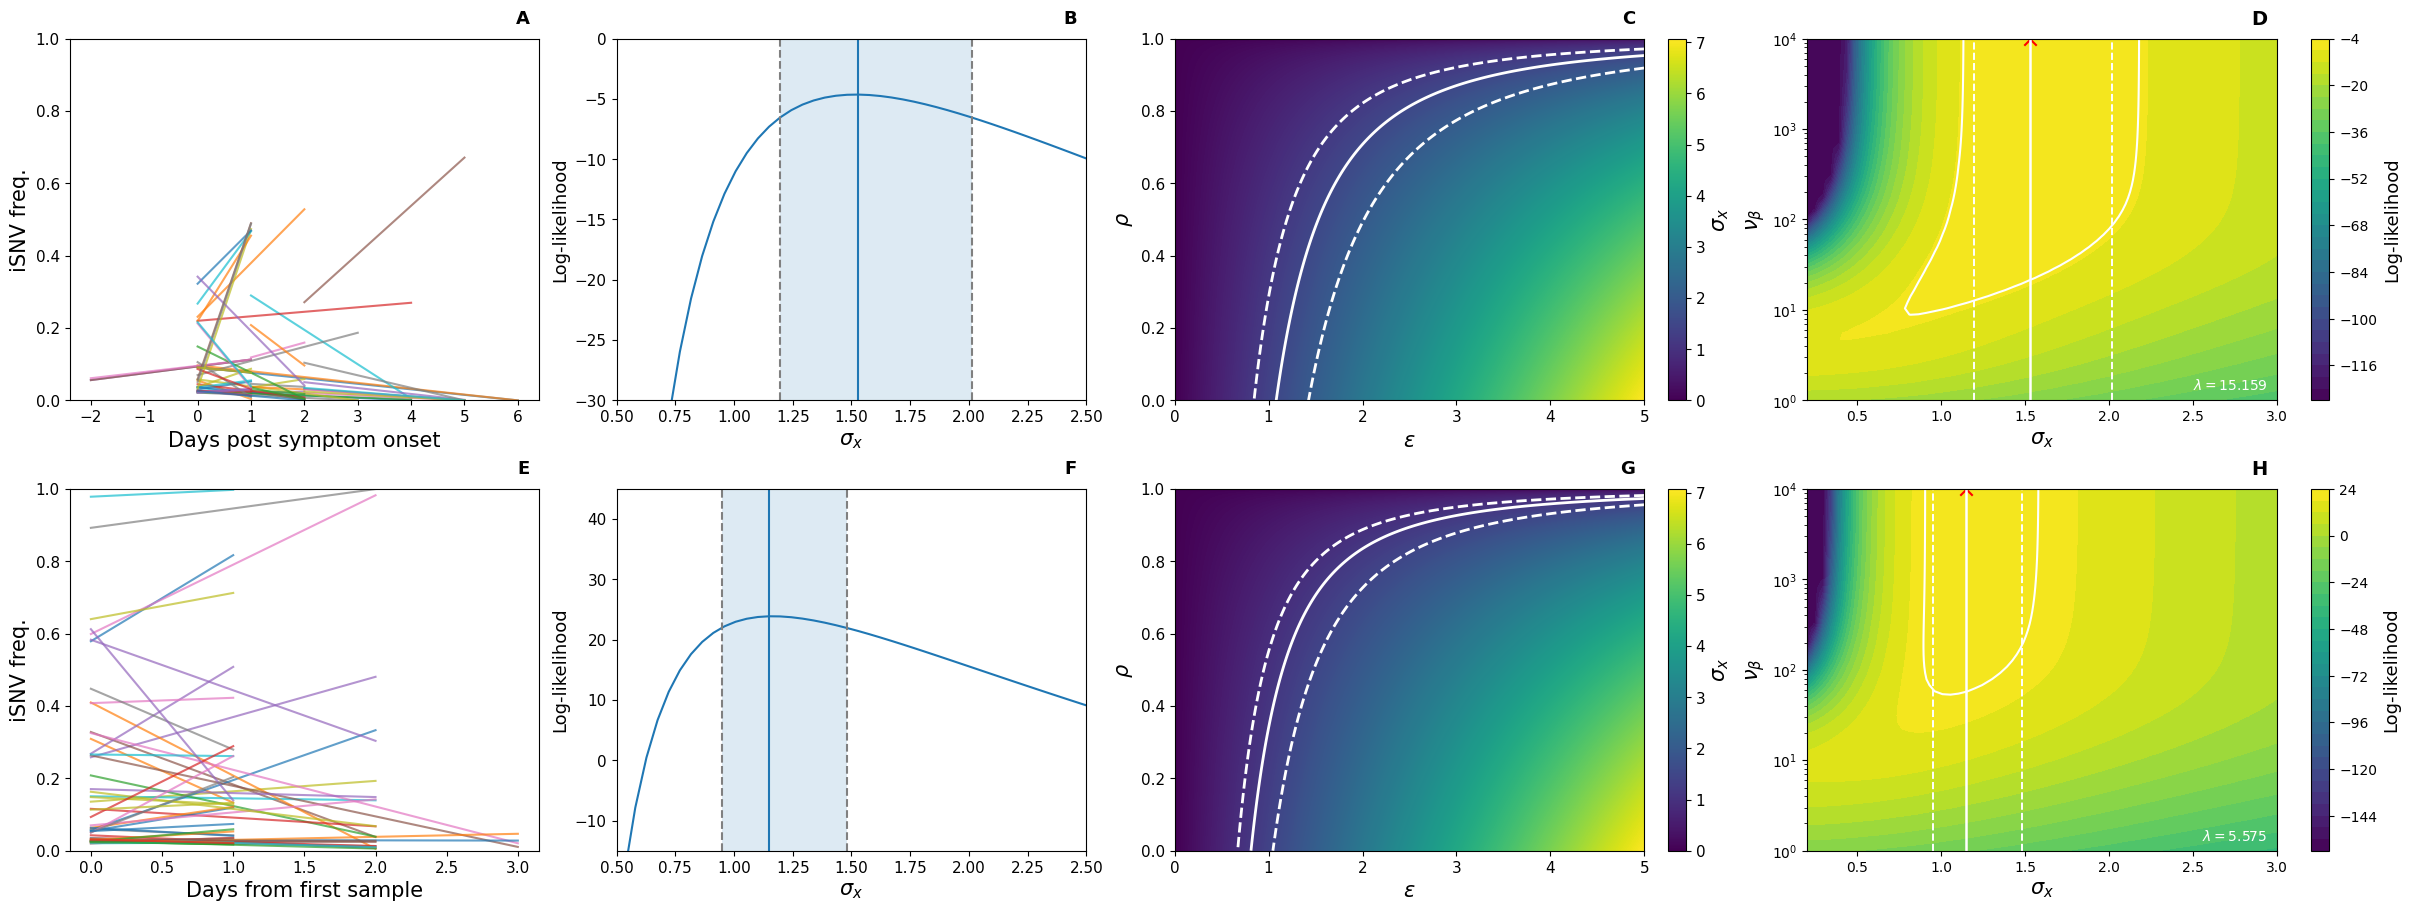

McCrone — MLE sigma_x = 1.528814  95% LR CI = [1.194979, 2.015377]
TonkinHill (full) — MLE sigma_x = 1.149153  95% LR CI = [0.948326, 1.479084]


In [38]:
# McCrone
d = np.load("heatmap_results/mccrone_logL_fitexp.npz")
mccrone_logL_fitexp = d["logL"]
F2_mcc = float(d["f2_mean"])

# Tonkin-Hill
d = np.load("heatmap_results/tonkinhill_logL_fitexp.npz")
tonkinhill_logL_fitexp = d["logL"]
F2_ton = float(d["f2_mean"])

make_combined_fig45(
    mccrone_df=McCrone_rename,
    tonkinHill_full_df=ton_filtered,
    mccrone_logL_fitexp=mccrone_logL_fitexp,
    tonkinhill_logL_fitexp=tonkinhill_logL_fitexp,
)

### Figure 6

In [43]:
mcc = prep_df(McCrone_rename)
mcc["abs_dX"] = np.abs(mcc["XT"] - mcc["X0"])
ton = prep_df(ton_filtered)
simulated_data = pd.read_csv("/Users/fionaxiao/Desktop/rotation/katia/simulated_brownian_data.csv")
simulated_15 = simulated_data[simulated_data["sigma"] == 1.5]


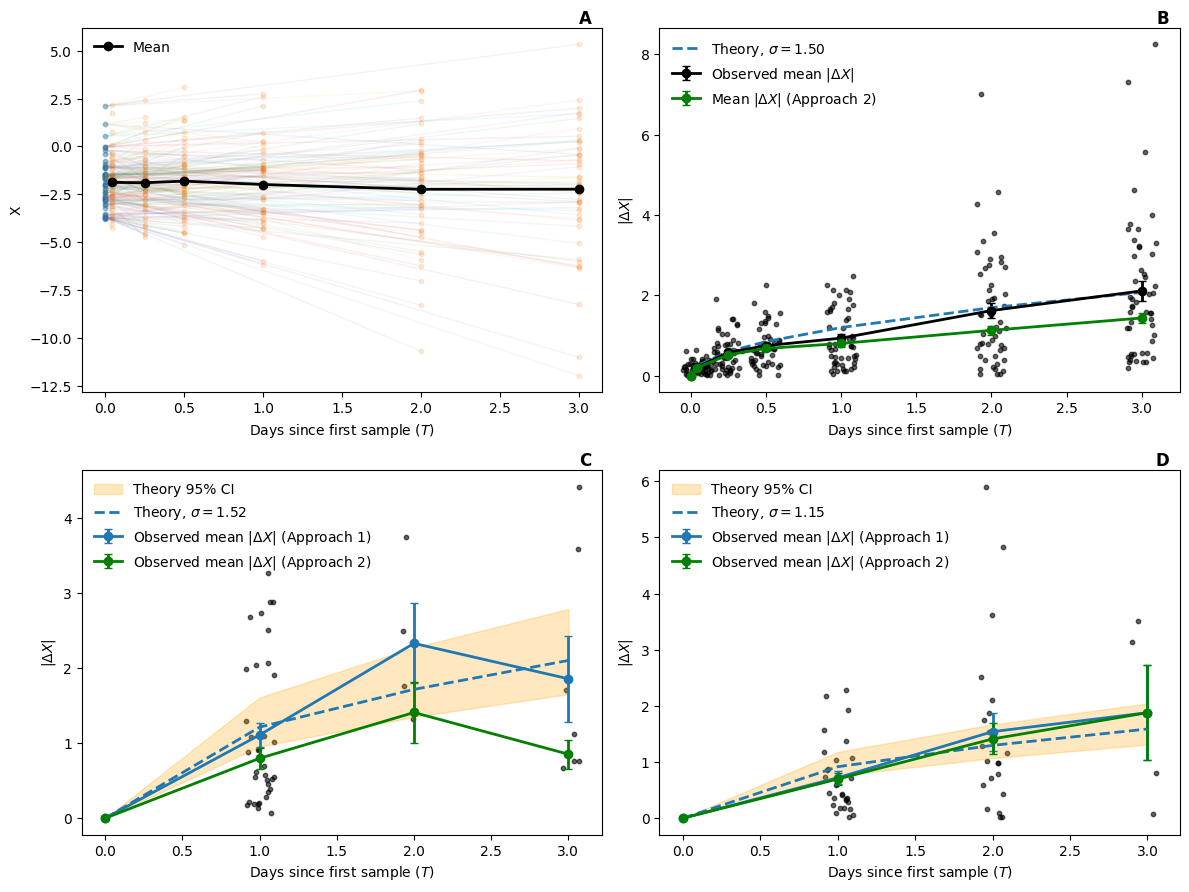

In [44]:
from scipy.special import expit

# ============================================================
# 1) Simulated data prep
# ============================================================

def prepare_simulated_dataset(df, sigma_key="sigma_15", dataset_name="Simulated"):
    """
    Expected columns in df:
        sigma_key, sigma, sample_id, T_hours, T_days, X0, XT, dX, abs_dX
    """
    sub = df[df["sigma_key"] == sigma_key].copy()
    if sub.empty:
        raise ValueError(f"No rows found for sigma_key={sigma_key!r}")

    out = pd.DataFrame({
        "T": sub["T_days"].astype(float),
        "X1": sub["X0"].astype(float),
        "X2": sub["XT"].astype(float),
        "abs_dX": sub["abs_dX"].astype(float),
    })
    out["dataset"] = dataset_name
    return out



def prepare_simulated_dataset_floor_lod(
    df, sigma_key="sigma_15", dataset_name="Simulated (floor LOD)", lod=0.02
):
    """
    Like prepare_simulated_dataset but floors simulated XT frequencies below LOD
    to LOD before computing abs_dX, to match the floor_below_lod treatment applied
    to real data.
    """
    sub = df[df["sigma_key"] == sigma_key].copy()
    if sub.empty:
        raise ValueError(f"No rows found for sigma_key={sigma_key!r}")

    X0 = sub["X0"].astype(float).values
    XT = sub["XT"].astype(float).values

    # Convert logit -> frequency, floor to [LOD, 1-LOD], convert back to logit
    fT = expit(XT)
    fT_floored = np.clip(fT, lod, 1.0 - lod)
    XT_floored = logit_transform(fT_floored)

    out = pd.DataFrame({
        "T": sub["T_days"].astype(float).values,
        "X1": X0,
        "X2": XT_floored,
        "abs_dX": np.abs(XT_floored - X0),
    })
    out["dataset"] = dataset_name
    return out

# ============================================================
# 2) Paired dataset preprocessing
# ============================================================

def preprocess_paired_frequency_dataset(
    df,
    mode,
    lod=0.02,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
):
    """
    mode:
        - "drop_zero": drop rows where f2 == 0
        - "floor_below_lod": replace f2 < lod with lod
        - "replace_zero_only": replace only f2 == 0 with lod
    """
    out = df.copy()

    out[f1_col] = pd.to_numeric(out[f1_col], errors="coerce")
    out[f2_col] = pd.to_numeric(out[f2_col], errors="coerce")
    out[dps1_col] = pd.to_numeric(out[dps1_col], errors="coerce")
    out[dps2_col] = pd.to_numeric(out[dps2_col], errors="coerce")

    out = out.dropna(subset=[dps1_col, dps2_col, f1_col, f2_col]).copy()

    if mode == "drop_zero":
        out = out[out[f2_col] != 0].copy()

    elif mode == "floor_below_lod":
        # lower bound
        out.loc[out[f2_col] < lod, f2_col] = lod
        
        # upper bound
        out.loc[out[f2_col] > (1 - lod), f2_col] = (1 - lod)

    elif mode == "replace_zero_only":
        out.loc[out[f2_col] == 0, f2_col] = lod

    else:
        raise ValueError(
            "mode must be one of: "
            "'drop_zero', 'floor_below_lod', 'replace_zero_only'"
        )

    return out


# ============================================================
# 3) Convert paired frequency dataset to common analysis format
# ============================================================

def prepare_paired_frequency_dataset(
    df,
    logit_transform,
    dataset_name="Dataset",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
):
    """
    Build common-format dataframe with columns:
        T, X1, X2, abs_dX, dataset
    """
    out = df.copy()

    out["T"] = out[dps2_col].astype(float) - out[dps1_col].astype(float)
    out["f1"] = out[f1_col].astype(float)
    out["f2"] = out[f2_col].astype(float)

    out["X1"] = logit_transform(out["f1"].values)
    out["X2"] = logit_transform(out["f2"].values)
    out["abs_dX"] = np.abs(out["X2"] - out["X1"])
    out["dataset"] = dataset_name

    return out[["T", "X1", "X2", "abs_dX", "dataset"]].copy()


# ============================================================
# 4) Filtering helpers
# ============================================================

def filter_timepoints_with_min_n(df_common, min_n=2):
    """
    Keep only T values with at least min_n observations.
    """
    counts = df_common.groupby("T").size()
    keep_T = counts[counts >= min_n].index
    return df_common[df_common["T"].isin(keep_T)].copy()


def exclude_specific_timepoints(df_common, exclude_T=None):
    """
    Remove specified T values.
    """
    if exclude_T is None:
        return df_common.copy()
    return df_common[~df_common["T"].isin(exclude_T)].copy()


# ============================================================
# 5) Summary helper
# ============================================================

def summarize_dataset(df_common):
    summary = (
        df_common.groupby("T", as_index=False)
        .agg(
            X_mean=("X2", "mean"),
            abs_dX_mean=("abs_dX", "mean"),
            n=("abs_dX", "size"),
            abs_dX_std=("abs_dX", "std"),
        )
        .sort_values("T")
    )

    summary["abs_dX_sem"] = summary["abs_dX_std"] / np.sqrt(summary["n"])
    return summary


def prepend_zero_for_curve(T_vals, y_vals):
    """
    Prepend (0,0) so a curve starts at zero.
    """
    T_vals = np.asarray(T_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    if len(T_vals) == 0:
        return np.array([0.0]), np.array([0.0])

    if T_vals[0] != 0:
        T_vals = np.insert(T_vals, 0, 0.0)
        y_vals = np.insert(y_vals, 0, 0.0)
    else:
        y_vals[0] = 0.0

    return T_vals, y_vals


# ============================================================
# 6) Plotting function: 2 x 2 layout
# Panels: A, B / D, F
# ============================================================

def plot_four_panel_analysis(
    df_sim,
    df_sim_floor,
    df_mccrone_drop_zero,
    df_mccrone_floor,
    df_tonkin_drop_zero,
    df_tonkin_floor,
    sigma_sim=1.5,
    sigma_mccrone=1.344862,
    sigma_mccrone_ci=(0.959950, 2.061255),
    sigma_tonkin=0.857143,
    sigma_tonkin_ci=(0.673524, 1.137108),
    xlabels=("T = DPS2 - DPS1", "T = DPS2 - DPS1", "T = DPS2 - DPS1"),
    figsize=(12, 9),
):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    letters = ["A", "B", "C", "D"]

    # --------------------------------------------------------
    # Panel A: simulated X vs T
    # --------------------------------------------------------
    ax = axes[0, 0]
    df_left = df_sim.dropna(subset=["T", "X1", "X2", "abs_dX"]).copy().sort_values("T")
    summary_left = summarize_dataset(df_left)

    for _, r in df_left.iterrows():
        ax.plot([0, r["T"]], [r["X1"], r["X2"]], alpha=0.08, linewidth=1)

    ax.scatter(np.zeros(len(df_left)), df_left["X1"], alpha=0.08, s=10)
    ax.scatter(df_left["T"], df_left["X2"], alpha=0.15, s=10)

    ax.plot(
        summary_left["T"],
        summary_left["X_mean"],
        "o-",
        linewidth=2,
        label="Mean",
        color = "black"
    )

    ax.set_xlabel(xlabels[0])
    ax.set_ylabel("X")
    ax.legend(frameon=False)
    ax.text(
        0.98, 1.05, letters[0],
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontweight="bold",
        fontsize=12
    )

    # --------------------------------------------------------
    # Helper for |ΔX| panels
    # --------------------------------------------------------
    def plot_abs_dx_panel(ax, df_blue, df_green, sigma, sigma_ci, xlabel, panel_letter,
                          blue_label, green_label, line_color="C0"):
        df_blue = df_blue.dropna(subset=["T", "X1", "X2", "abs_dX"]).copy().sort_values("T")
        summary_blue = summarize_dataset(df_blue)

        rng = np.random.default_rng(seed=42)
        jitter = rng.uniform(-0.1, 0.1, size=len(df_blue))
        ax.scatter(df_blue["T"] + jitter, df_blue["abs_dX"], alpha=0.6, s=10, color="black")

        T_blue = summary_blue["T"].to_numpy(dtype=float)
        y_blue = summary_blue["abs_dX_mean"].to_numpy(dtype=float)
        sem_blue = summary_blue["abs_dX_sem"].to_numpy(dtype=float)

        T_blue_plot, y_blue_plot = prepend_zero_for_curve(T_blue, y_blue)
        if len(T_blue_plot) == len(sem_blue) + 1:
            sem_blue_plot = np.insert(sem_blue, 0, 0.0)
        else:
            sem_blue_plot = sem_blue.copy()
            if len(sem_blue_plot) > 0:
                sem_blue_plot[0] = 0.0

        ax.errorbar(
            T_blue_plot,
            y_blue_plot,
            yerr=sem_blue_plot,
            fmt="o-",
            linewidth=2,
            capsize=3,
            color=line_color,
            label=blue_label,
        )

        if df_green is not None:
            df_green = df_green.dropna(subset=["T", "X1", "X2", "abs_dX"]).copy().sort_values("T")
            summary_green = summarize_dataset(df_green)

            T_green = summary_green["T"].to_numpy(dtype=float)
            y_green = summary_green["abs_dX_mean"].to_numpy(dtype=float)
            sem_green = summary_green["abs_dX_sem"].to_numpy(dtype=float)

            T_green_plot, y_green_plot = prepend_zero_for_curve(T_green, y_green)
            if len(T_green_plot) == len(sem_green) + 1:
                sem_green_plot = np.insert(sem_green, 0, 0.0)
            else:
                sem_green_plot = sem_green.copy()
                if len(sem_green_plot) > 0:
                    sem_green_plot[0] = 0.0

            ax.errorbar(
                T_green_plot,
                y_green_plot,
                yerr=sem_green_plot,
                fmt="o-",
                linewidth=2,
                capsize=3,
                color="green",
                label=green_label,
            )

        if sigma is not None:
            t_candidates = [0.0]
            t_candidates.extend(summary_blue["T"].tolist())

            if df_green is not None and len(df_green) > 0:
                t_candidates.extend(summary_green["T"].tolist())

            T_theory = np.array(sorted(set(float(t) for t in t_candidates)))
            theory = sigma * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)

            if sigma_ci is not None:
                sigma_lo, sigma_hi = sigma_ci
                theory_lo = sigma_lo * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)
                theory_hi = sigma_hi * np.sqrt(T_theory) * np.sqrt(2.0 / np.pi)

                ax.fill_between(
                    T_theory,
                    theory_lo,
                    theory_hi,
                    color="orange",
                    alpha=0.25,
                    label="Theory 95% CI",
                )

            ax.plot(
                T_theory,
                theory,
                "--",
                linewidth=2,
                label=rf"Theory, $\sigma={sigma:.2f}$",
            )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(r"$|\Delta X|$")
        ax.legend(frameon=False)
        ax.text(
            0.98, 1.05, panel_letter,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontweight="bold",
            fontsize=12
        )

    # --------------------------------------------------------
    # Panel B: simulated |ΔX| vs T
    # --------------------------------------------------------
    plot_abs_dx_panel(
        ax=axes[0, 1],
        df_blue=df_sim.copy(),
        df_green=df_sim_floor.copy() if df_sim_floor is not None else None,
        sigma=sigma_sim,
        sigma_ci=None,
        xlabel=xlabels[0],
        panel_letter=letters[1],
        blue_label=r"Observed mean $|\Delta X|$",
        green_label=r"Mean $|\Delta X|$ (Approach 2)",
        line_color="black",
    )

    # --------------------------------------------------------
    # Panel D: McCrone |ΔX| vs T
    # --------------------------------------------------------
    plot_abs_dx_panel(
        ax=axes[1, 0],
        df_blue=df_mccrone_drop_zero.copy(),
        df_green=df_mccrone_floor.copy(),
        sigma=sigma_mccrone,
        sigma_ci=sigma_mccrone_ci,
        xlabel=xlabels[1],
        panel_letter=letters[2],
        blue_label=r"Observed mean $|\Delta X|$ (Approach 1)",
        green_label=r"Observed mean $|\Delta X|$ (Approach 2)",
    )

    # --------------------------------------------------------
    # Panel F: TonkinHill |ΔX| vs T
    # --------------------------------------------------------
    plot_abs_dx_panel(
        ax=axes[1, 1],
        df_blue=df_tonkin_drop_zero.copy(),
        df_green=df_tonkin_floor.copy(),
        sigma=sigma_tonkin,
        sigma_ci=sigma_tonkin_ci,
        xlabel=xlabels[2],
        panel_letter=letters[3],
        blue_label=r"Observed mean $|\Delta X|$ (Approach 1)",
        green_label=r"Observed mean $|\Delta X|$ (Approach 2)",
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 7) Build datasets
# ============================================================

# Simulated
df_sim_common = prepare_simulated_dataset(
    df=simulated_data,
    sigma_key="sigma_15",
    dataset_name="Simulated"
)

df_sim_floor_common = prepare_simulated_dataset_floor_lod(
    df=simulated_data,
    sigma_key="sigma_15",
    dataset_name="Simulated (floor LOD)",
    lod=0.02,
)

# McCrone
mccrone_drop_zero = preprocess_paired_frequency_dataset(
    df=mcc,
    mode="drop_zero",
    lod=0.02,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

mccrone_floor = preprocess_paired_frequency_dataset(
    df=mcc,
    mode="floor_below_lod",
    lod=0.02,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_mccrone_drop_zero_common = prepare_paired_frequency_dataset(
    df=mccrone_drop_zero,
    logit_transform=logit_transform,
    dataset_name="McCrone",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_mccrone_floor_common = prepare_paired_frequency_dataset(
    df=mccrone_floor,
    logit_transform=logit_transform,
    dataset_name="McCrone",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

# Exclude McCrone day 4 and day 6
df_mccrone_drop_zero_common = exclude_specific_timepoints(
    df_mccrone_drop_zero_common,
    exclude_T=[4, 6]
)

df_mccrone_floor_common = exclude_specific_timepoints(
    df_mccrone_floor_common,
    exclude_T=[4, 6]
)

# Keep only time points with >1 datapoint
df_mccrone_drop_zero_common = filter_timepoints_with_min_n(
    df_mccrone_drop_zero_common,
    min_n=2
)

df_mccrone_floor_common = filter_timepoints_with_min_n(
    df_mccrone_floor_common,
    min_n=2
)

# TonkinHill_full
tonkin_drop_zero = preprocess_paired_frequency_dataset(
    df=ton,
    mode="drop_zero",
    lod=0.005,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

tonkin_floor = preprocess_paired_frequency_dataset(
    df=ton,
    mode="floor_below_lod",
    lod=0.005,
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_tonkin_drop_zero_common = prepare_paired_frequency_dataset(
    df=tonkin_drop_zero,
    logit_transform=logit_transform,
    dataset_name="TonkinHill_full",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)

df_tonkin_floor_common = prepare_paired_frequency_dataset(
    df=tonkin_floor,
    logit_transform=logit_transform,
    dataset_name="TonkinHill_full",
    dps1_col="DPS1",
    dps2_col="DPS2",
    f1_col="DPS1 Frequency",
    f2_col="DPS2 Frequency",
)


# Keep only time points with >1 datapoint
df_tonkin_drop_zero_common = filter_timepoints_with_min_n(
    df_tonkin_drop_zero_common,
    min_n=2
)

df_tonkin_floor_common = filter_timepoints_with_min_n(
    df_tonkin_floor_common,
    min_n=2
)

# ============================================================
# 8) Plot
# ============================================================

plot_four_panel_analysis(
    df_sim=df_sim_common,
    df_sim_floor=df_sim_floor_common,
    df_mccrone_drop_zero=df_mccrone_drop_zero_common,
    df_mccrone_floor=df_mccrone_floor_common,
    df_tonkin_drop_zero=df_tonkin_drop_zero_common,
    df_tonkin_floor=df_tonkin_floor_common,
    sigma_sim=1.5,
    sigma_mccrone=1.52,
    sigma_mccrone_ci=(1.194979, 2.015377),
    sigma_tonkin=1.149153 ,
    sigma_tonkin_ci=(0.948326, 1.479084),
    xlabels=(r"Days since first sample ($T$)", r"Days since first sample ($T$)", r"Days since first sample ($T$)"),
) 


In [ ]:
df_tonkin_drop_zero_common.to_csv("data/simulated_brownian_data.csv", index=False)
df_mccrone_drop_zero_common.to_csv("data/simulated_brownian_data.csv", index=False)
df_sim_common.to_csv("data/df_sim_common.csv", index=False)


### Figure 7

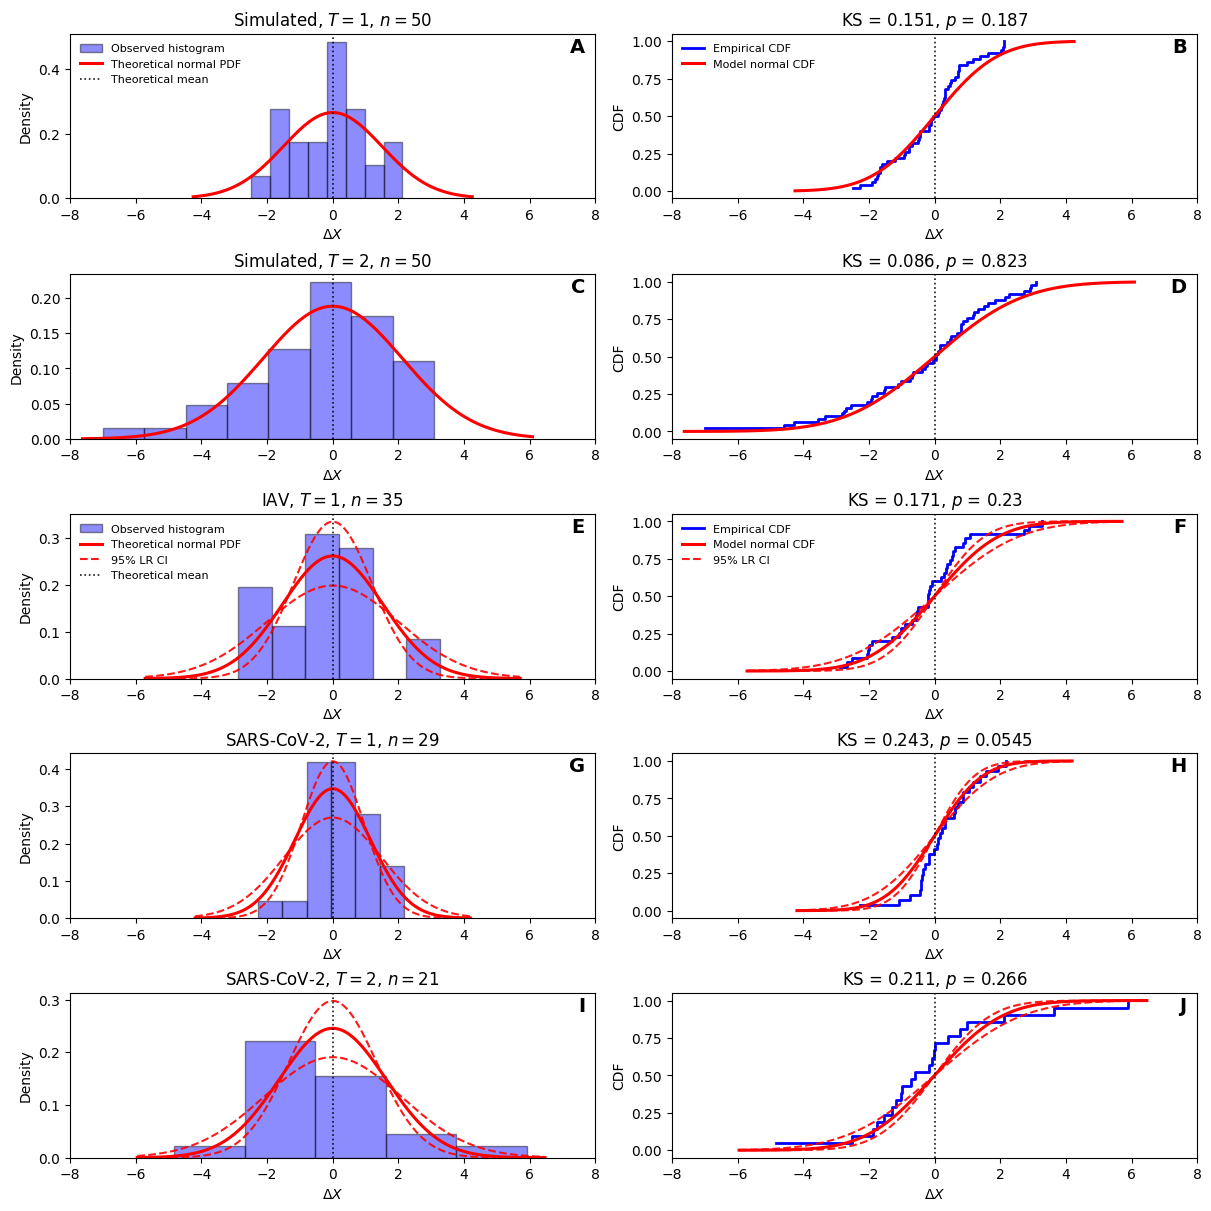

,dataset,T,n,sigma_mle,KS_statistic,p_value,observed_mean_dX,observed_sd_dX
0,Simulated,1.0,50,1.500000,0.150514,0.187273,-0.108455,1.174275
1,Simulated,2.0,50,1.500000,0.085987,0.822742,-0.356854,2.116923
2,IAV,1.0,35,1.528814,0.170964,0.230131,-0.242949,1.462439
3,SARS-CoV-2,1.0,29,1.149153,0.242825,0.054464,0.254163,0.931010
4,SARS-CoV-2,2.0,21,1.149153,0.211317,0.265786,-0.223664,2.208731


In [45]:
from scipy import stats
import string

# ============================================================
# Parameters
# ============================================================

# Simulated data
sigma_sim = 1.5

# IAV / McCrone
sigma_iav_mle = 1.528814
sigma_iav_ci_low = 1.194979
sigma_iav_ci_high = 2.015377

# TonkinHill
sigma_tonkin_mle = 1.149153
sigma_tonkin_ci_low = 0.948326
sigma_tonkin_ci_high = 1.479084

# ============================================================
# Helper: prepare dataframe
# ============================================================

def prepare_dx_df(df):
    out = df.copy()
    out["X1"] = pd.to_numeric(out["X1"], errors="coerce")
    out["X2"] = pd.to_numeric(out["X2"], errors="coerce")
    out["T"] = pd.to_numeric(out["T"], errors="coerce")
    out["dX"] = out["X2"] - out["X1"]
    out["dX"] = pd.to_numeric(out["dX"], errors="coerce")
    out = out.dropna(subset=["T", "dX"]).copy()
    return out

df_sim_plot = prepare_dx_df(df_sim_common)
df_iav_plot = prepare_dx_df(df_mccrone_drop_zero_common)
df_tonkin_plot = prepare_dx_df(df_tonkin_drop_zero_common)

# ============================================================
# Panel specifications: one row per entry
# ============================================================

panel_specs = [
    {
        "row_name": "Simulated",
        "T": 1.0,
        "df": df_sim_plot,
        "sigma_mle": sigma_sim,
        "sigma_ci_low": None,
        "sigma_ci_high": None,
    },
    {
        "row_name": "Simulated",
        "T": 2.0,
        "df": df_sim_plot,
        "sigma_mle": sigma_sim,
        "sigma_ci_low": None,
        "sigma_ci_high": None,
    },
    {
        "row_name": "IAV",
        "T": 1.0,
        "df": df_iav_plot,
        "sigma_mle": sigma_iav_mle,
        "sigma_ci_low": sigma_iav_ci_low,
        "sigma_ci_high": sigma_iav_ci_high,
    },
    {
        "row_name": "SARS-CoV-2",
        "T": 1.0,
        "df": df_tonkin_plot,
        "sigma_mle": sigma_tonkin_mle,
        "sigma_ci_low": sigma_tonkin_ci_low,
        "sigma_ci_high": sigma_tonkin_ci_high,
    },
    {
        "row_name": "SARS-CoV-2",
        "T": 2.0,
        "df": df_tonkin_plot,
        "sigma_mle": sigma_tonkin_mle,
        "sigma_ci_low": sigma_tonkin_ci_low,
        "sigma_ci_high": sigma_tonkin_ci_high,
    },
]

# ============================================================
# Plot
# ============================================================

n_rows = len(panel_specs)
n_cols = 2

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(12, 12),
    constrained_layout=True
)

panel_labels = list(string.ascii_uppercase)
label_i = 0

ks_summary = []

for i, spec in enumerate(panel_specs):
    show_legend = i in [0, 2]   
    row_name = spec["row_name"]
    T_val = spec["T"]
    df_use = spec["df"]
    sigma_mle = spec["sigma_mle"]
    sigma_ci_low = spec["sigma_ci_low"]
    sigma_ci_high = spec["sigma_ci_high"]

    # Select row data
    sub = df_use[np.isclose(df_use["T"], T_val)].copy()
    x_obs = sub["dX"].to_numpy(dtype=float)
    n = len(x_obs)

    if n == 0:
        axes[i, 0].axis("off")
        axes[i, 1].axis("off")
        continue

    x_sorted = np.sort(x_obs)

    # Standard deviations
    sd_mle = sigma_mle * np.sqrt(T_val)

    has_ci = (sigma_ci_low is not None) and (sigma_ci_high is not None)
    if has_ci:
        sd_low = sigma_ci_low * np.sqrt(T_val)
        sd_high = sigma_ci_high * np.sqrt(T_val)
        max_sd = max(sd_mle, sd_low, sd_high)
    else:
        max_sd = sd_mle

    # KS test against MLE model
    ks_stat, p_value = stats.kstest(
        x_obs,
        "norm",
        args=(0, sd_mle)
    )

    ks_summary.append({
        "dataset": row_name,
        "T": T_val,
        "n": n,
        "sigma_mle": sigma_mle,
        "KS_statistic": ks_stat,
        "p_value": p_value,
        "observed_mean_dX": np.mean(x_obs),
        "observed_sd_dX": np.std(x_obs, ddof=1) if n > 1 else np.nan
    })

    # Common x-grid
    x_min = min(x_obs.min(), stats.norm.ppf(0.005, loc=0, scale=max_sd))
    x_max = max(x_obs.max(), stats.norm.ppf(0.995, loc=0, scale=max_sd))
    x_pad = 0.05 * (x_max - x_min) if x_max > x_min else 0.5
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 500)

    # ========================================================
    # Left column: histogram + PDF
    # ========================================================
    ax = axes[i, 0]

    bins = min(12, max(3, int(np.sqrt(n)) + 1))

    ax.hist(
        x_obs,
        bins=bins,
        density=True,
        alpha=0.45,
        color="blue",
        edgecolor="black",
        label="Observed histogram"
    )

    pdf_mle = stats.norm.pdf(x_grid, loc=0, scale=sd_mle)
    ax.plot(
        x_grid,
        pdf_mle,
        color="red",
        linewidth=2.2,
        label="Theoretical normal PDF"
    )

    if has_ci:
        pdf_low = stats.norm.pdf(x_grid, loc=0, scale=sd_low)
        pdf_high = stats.norm.pdf(x_grid, loc=0, scale=sd_high)

        ax.plot(
            x_grid,
            pdf_low,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.9,
            label="95% LR CI"
        )
        ax.plot(
            x_grid,
            pdf_high,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.9
        )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.9,
        label="Theoretical mean"
    )

    ax.set_title(f"{row_name}, $T = {T_val:g}$, $n={n}$")
    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("Density")
    if show_legend:
        ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(-8, 8)
    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1

    # ========================================================
    # Right column: ECDF + CDF
    # ========================================================
    ax = axes[i, 1]

    ecdf = np.arange(1, n + 1) / n
    cdf_mle = stats.norm.cdf(x_grid, loc=0, scale=sd_mle)

    ax.step(
        x_sorted,
        ecdf,
        where="post",
        color="blue",
        linewidth=2,
        label="Empirical CDF"
    )

    ax.plot(
        x_grid,
        cdf_mle,
        color="red",
        linewidth=2.2,
        label="Model normal CDF"
    )

    if has_ci:
        cdf_low = stats.norm.cdf(x_grid, loc=0, scale=sd_low)
        cdf_high = stats.norm.cdf(x_grid, loc=0, scale=sd_high)

        ax.plot(
            x_grid,
            cdf_low,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.9,
            label="95% LR CI"
        )
        ax.plot(
            x_grid,
            cdf_high,
            color="red",
            linestyle="--",
            linewidth=1.5,
            alpha=0.9
        )

    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        alpha=0.9
    )

    ax.set_title(
        f"KS = {ks_stat:.3f}, $p$ = {p_value:.3g}"
    )
    ax.set_xlabel(r"$\Delta X$")
    ax.set_ylabel("CDF")
    if show_legend:
        ax.legend(frameon=False, fontsize=8)
    ax.set_xlim(-8, 8)
    ax.text(
        0.98, 0.98, panel_labels[label_i],
        transform=ax.transAxes,
        ha="right", va="top",
        fontsize=14, fontweight="bold"
    )
    label_i += 1

plt.show()

# ============================================================
# KS summary table
# ============================================================

ks_summary_df = pd.DataFrame(ks_summary)
ks_summary_df

### Figure 8

In [46]:
McCrone_rename["T"] = McCrone_rename["DPS2"] - McCrone_rename["DPS1"]
mccrone_T1 = McCrone_rename[(McCrone_rename['T'] == 1) & (McCrone_rename['DPS1 Frequency'] >= 0.02)]
ton = pd.read_csv("data/Table_S2.csv")
ton_T1 = ton[ton["Time between samples (days)"] == 1]
van = pd.read_csv("data/Table_S3.csv")
van

,Individual ID,iSNV,First sample (in days post symptom onset),Second sample (in days post symptom onset),First sample iSNV frequency,Second sample iSNV frequency
0,1-5,PB2_A581G,4,6,0.479035,0.367066
1,20352,PA_G1923T,3,4,0.062417,0.095038
2,20352,PA_G1923T,4,5,0.095038,0.000000
3,20352,PB1_C1344T,5,6,0.162707,0.000000
4,20361,PB1_T1902C,3,5,0.408673,0.301644
...,...,...,...,...,...,...
81,37341,PA_G1789T,5,6,0.079625,0.051674
82,37355,PB1_G799A,2,5,0.156777,0.000000
83,37356,PB1_A1370G,4,6,0.043185,0.057442
84,37364,PB2_A1188G,2,5,0.227924,0.399105


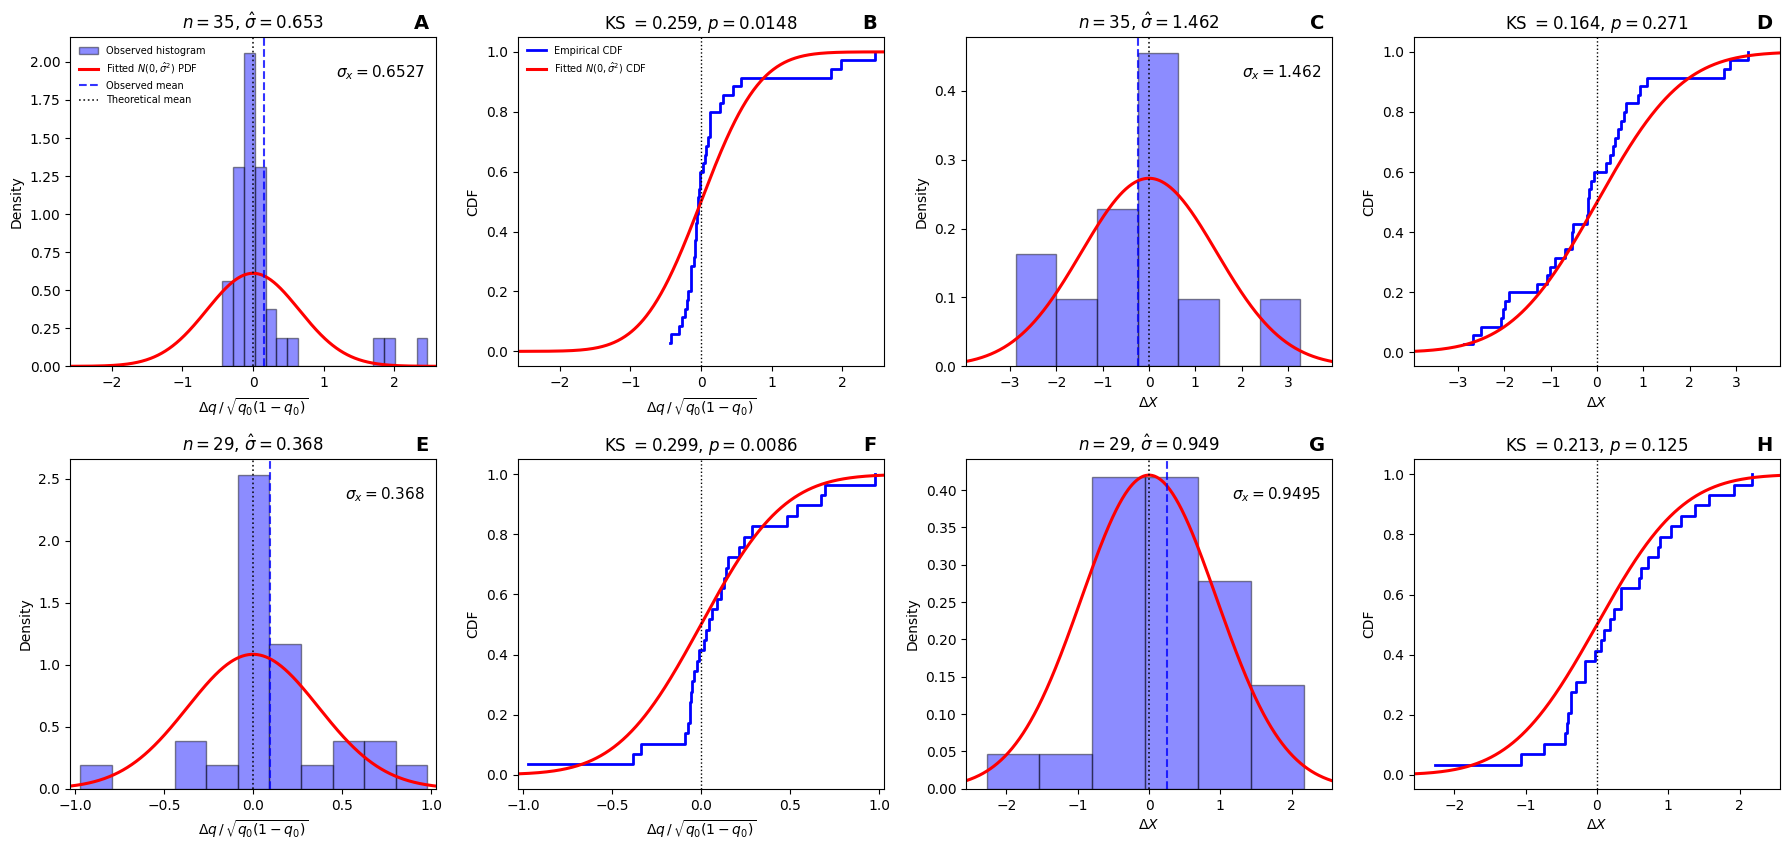

In [49]:

# ============================================================
# Value extractors (T = 1 only)
# ============================================================
def wf_values(df, q0_col, q1_col, t_col, t=1.0):
    """Wright-Fisher: standardized signed frequency change s = dq / sqrt(q0(1-q0))."""
    q0_all = df[q0_col].to_numpy(float)
    q1_all = df[q1_col].to_numpy(float)
    T_all  = df[t_col].to_numpy(float)
    dq_all = q1_all - q0_all
    sel = (T_all == t) & np.isfinite(dq_all) & (q0_all > 0) & (q0_all < 1)
    q0 = q0_all[sel]
    return dq_all[sel] / np.sqrt(q0 * (1 - q0))

def env_values(df, x1_col, x2_col, t_col, t=1.0):
    """Environmental stochasticity: dX = X2 - X1 on the transformed scale."""
    d = df.copy()
    d["dX"] = d[x2_col] - d[x1_col]
    d = d.dropna(subset=[t_col, "dX"])
    d[t_col] = d[t_col].astype(float)
    v = d.loc[d[t_col] == t, "dX"].to_numpy(float)
    return v[np.isfinite(v)]

# ============================================================
# Panel painter: fills a (histogram, CDF) pair for one dataset/model
# ============================================================
def paint_pair(ax_hist, ax_cdf, v, xlabel, header, lbl_hist, lbl_cdf,
               show_legend=False):
    v = np.asarray(v, float)
    v = v[np.isfinite(v)]
    n = len(v)

    # MLE estimates with mean pinned at 0
    var_hat = np.mean(v**2)          # fitted variance
    sigma_hat = np.sqrt(var_hat)     # fitted standard deviation

    ks_stat, p_value = stats.kstest(v, "norm", args=(0, sigma_hat))

    x_hi = 1.05 * max(np.abs(v).max(),
                      stats.norm.ppf(0.995, scale=sigma_hat))
    x_grid = np.linspace(-x_hi, x_hi, 500)

    # ---- histogram + fitted N(0, sigma_hat^2) pdf ----
    ax_hist.hist(v, bins="auto", density=True, alpha=0.45,
                 color="blue", edgecolor="black",
                 label="Observed histogram")

    ax_hist.plot(x_grid, stats.norm.pdf(x_grid, scale=sigma_hat),
                 color="red", linewidth=2.2,
                 label=r"Fitted $N(0,\hat\sigma^2)$ PDF")

    ax_hist.axvline(np.mean(v), color="blue", linestyle="--",
                    linewidth=1.5, alpha=0.8,
                    label="Observed mean")

    ax_hist.axvline(0, color="black", linestyle=":",
                    linewidth=1.2, alpha=0.9,
                    label="Theoretical mean")

    ax_hist.set_xlim(-x_hi, x_hi)
    ax_hist.set_title(
        rf"$n={n}$, $\hat\sigma={sigma_hat:.3f}$",
        fontsize=12
    )
    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel("Density")

    # Panel label: A, C, E, or G
    ax_hist.text(0.98, 1.07, lbl_hist,
                 transform=ax_hist.transAxes,
                 ha="right", va="top",
                 fontsize=14, fontweight="bold")

    # ---- NEW: fitted variance annotation ----
    ax_hist.text(
        0.97, 0.92,
        rf"${{\sigma_x}} = {np.sqrt(var_hat):.4g}$",
        transform=ax_hist.transAxes,
        ha="right", va="top",
        fontsize=11,
    )

    if show_legend:
        ax_hist.legend(frameon=False, fontsize=7)

    # ---- empirical CDF vs fitted N(0, sigma_hat^2) CDF ----
    v_sorted = np.sort(v)
    ecdf = np.arange(1, n + 1) / n

    ax_cdf.step(v_sorted, ecdf, where="post",
                color="blue", linewidth=2,
                label="Empirical CDF")

    ax_cdf.plot(x_grid, stats.norm.cdf(x_grid, scale=sigma_hat),
                color="red", linewidth=2.2,
                label=r"Fitted $N(0,\hat\sigma^2)$ CDF")

    ax_cdf.axvline(0, color="black", linestyle=":", linewidth=1)

    ax_cdf.set_xlim(-x_hi, x_hi)
    ax_cdf.set_title(
        rf"KS $= {ks_stat:.3f}$, $p = {p_value:.3g}$",
        fontsize=12
    )
    ax_cdf.set_xlabel(xlabel)
    ax_cdf.set_ylabel("CDF")

    ax_cdf.text(0.98, 1.07, lbl_cdf,
                transform=ax_cdf.transAxes,
                ha="right", va="top",
                fontsize=14, fontweight="bold")

    if show_legend:
        ax_cdf.legend(frameon=False, fontsize=7)

# ============================================================
# Assemble the 2 x 4 grid
# ============================================================
WF_XLABEL  = r"$\Delta q\,/\,\sqrt{q_0(1-q_0)}$"
ENV_XLABEL = r"$\Delta X$"

fig, axes = plt.subplots(2, 4, figsize=(18.0, 8.6))

# ---- Row 0: McCrone (IAV) ----
paint_pair(axes[0, 0], axes[0, 1],
           wf_values(mccrone_T1, "DPS1 Frequency", "DPS2 Frequency", "T"),
           WF_XLABEL, "McCrone IAV · Wright–Fisher", "A", "B",
           show_legend=True)
paint_pair(axes[0, 2], axes[0, 3],
           env_values(df_mccrone_drop_zero_common, "X1", "X2", "T"),
           ENV_XLABEL, "McCrone IAV · Env. stochasticity", "C", "D")

# ---- Row 1: Tonkin Hill (SARS-CoV-2) ----
paint_pair(axes[1, 0], axes[1, 1],
           wf_values(ton_T1, "First iSNV frequency", "Second iSNV frequency",
                     "Time between samples (days)"),
           WF_XLABEL, "Tonkin Hill CoV · Wright–Fisher", "E", "F")
paint_pair(axes[1, 2], axes[1, 3],
           env_values(df_tonkin_drop_zero_common, "X1", "X2", "T"),
           ENV_XLABEL, "Tonkin Hill CoV · Env. stochasticity", "G", "H")

plt.tight_layout()
plt.show()




### Figure 9

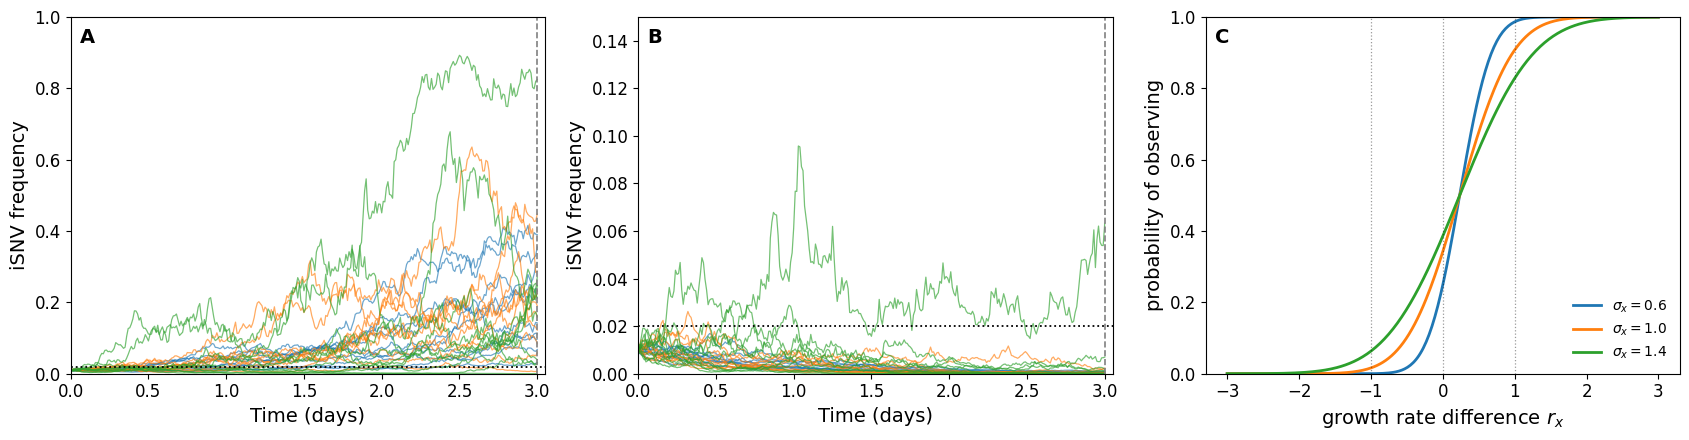

In [52]:
# ============================================================
# Panel A: Simulated trajectories r_x=+1 (10 per sigma_x, fixed f0=0.01)
# Panel B: Simulated trajectories r_x=-1 (10 per sigma_x, fixed f0=0.01)
# Panel C: Analytical P(observe at T) vs r_x — three sigma_x values
# ============================================================
from scipy.stats import norm as sp_norm

# ---- Parameters ----
T_obs    = 3.0
f_thresh = 0.02
f0_fixed = 0.01
x_thresh = np.log(f_thresh / (1.0 - f_thresh))   # logit(0.02)
X0_fixed = np.log(f0_fixed / (1.0 - f0_fixed))   # logit(0.01)

sigma_x_vals = [0.6, 1.0, 1.4]
dt_sim       = 0.01
t            = np.arange(0.0, T_obs + dt_sim * 0.5, dt_sim)
rx_grid      = np.linspace(-3, 3, 300)

# ---- Simulation with fixed initial condition ----

def simulate_fixed_X0(rx, sigma_x, n_traj, t, X0):
    n_steps = len(t) - 1
    dt      = t[1] - t[0]
    X       = np.zeros((n_traj, len(t)))
    X[:, 0] = X0
    dW = np.random.normal(0.0, np.sqrt(dt), size=(n_traj, n_steps))
    for k in range(n_steps):
        X[:, k + 1] = X[:, k] + rx * dt + sigma_x * dW[:, k]
    return 1.0 / (1.0 + np.exp(-X))

# ---- Analytical P(observe) with fixed X0 ----

def p_observe_analytical(rx_grid, sigma_x, X0, T, x_thresh):
    z = (X0 + rx_grid * T - x_thresh) / (sigma_x * np.sqrt(T))
    return sp_norm.cdf(z)

# ---- Plot ----
label_font, tick_font = 14, 12
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 4.5))

# ---- Shared helper for trajectory panels ----
def plot_traj_panel(ax, rx, label):
    for sigma_x, color in zip(sigma_x_vals, colors):
        f2 = simulate_fixed_X0(rx, sigma_x, 10, t, X0_fixed)
        for i in range(10):
            ax.plot(t, f2[i], color=color, alpha=0.65, linewidth=0.9)
        ax.plot([], [], color=color, linewidth=1.5, label=rf'$\sigma_x={sigma_x}$')
    ax.axhline(f_thresh, color='k',    linestyle=':', linewidth=1.3, label='LOD = 2%')
    ax.axvline(T_obs,    color='grey', linestyle='--', linewidth=1.2, label='T = 3 d')
    ax.set_xlabel('Time (days)', fontsize=label_font)
    ax.set_ylabel(r'iSNV frequency', fontsize=label_font)
    #rx_sign = '+' if rx >= 0 else ''
    #ax.set_title(rf'$r_x={rx_sign}{rx}$ day$^{{-1}}$, $f_0={f0_fixed}$',fontsize=11)
    ax.set_ylim(0, 1);  ax.set_xlim(0, T_obs + 0.05)
    ax.tick_params(labelsize=tick_font)
    ax.text(0.02, 0.97, label, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top')

plot_traj_panel(ax1, rx=+1, label='A')
plot_traj_panel(ax2, rx=-1, label='B')
ax2.set_ylim(0, 0.15)
# Panel C: analytical P(observe)
for sigma_x, color in zip(sigma_x_vals, colors):
    p = p_observe_analytical(rx_grid, sigma_x, X0_fixed, T_obs, x_thresh)
    ax3.plot(rx_grid, p, color=color, linewidth=2,
             label=rf'$\sigma_x={sigma_x}$')
ax3.axvline(0.0, color='k', linestyle=':', linewidth=0.9, alpha=0.4)
ax3.axvline(1.0, color='k', linestyle=':', linewidth=0.9, alpha=0.4)
ax3.axvline(-1.0, color='k', linestyle=':', linewidth=0.9, alpha=0.4)
ax3.set_xlabel(r'growth rate difference $r_x$', fontsize=label_font)
ax3.set_ylabel(r'probability of observing', fontsize=label_font)
#ax3.set_title(rf'$T={T_obs}$ d, LOD=2%, $f_0={f0_fixed}$ (analytical)',fontsize=11)
ax3.legend(fontsize=10, frameon=False, loc='lower right')
ax3.set_ylim(0, 1)
ax3.tick_params(labelsize=tick_font)
ax3.text(0.02, 0.97, 'C', transform=ax3.transAxes,
         fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.show()
